# Detección de Anomalías y Predicción de Vida Útil Remanente (RUL) en Motores Turbofán

**Autor:** Rafael Pecino Bonilla — Máster Universitario en Inteligencia Artificial (MUIA), UAX
**Tutor:** Jesús Gil
**Dataset:** NASA C-MAPSS (FD001–FD004)

Sistema jerárquico de mantenimiento predictivo que combina detección de anomalías no supervisada y estimación de RUL con cuantificación de incertidumbre. Componentes:

| # | Modelo | Rol |
|---|---|---|
| 1 | **Variational Autoencoder** (Conv1D) | Detección de anomalías y compuerta (gating) |
| 2 | **Random Forest** + feature engineering | Baseline interpretable de regresión |
| 3 | **1D-CNN + LSTM** | Regresión de RUL |
| 4 | **Transformer** + positional encoding | Regresión de RUL |
| 5 | **DeepSurv** (Cox) | Análisis de supervivencia (exploratorio, no integrado) |

La estimación de RUL se acompaña de incertidumbre epistémica mediante **MC Dropout**. El cuaderno es autocontenido y compatible con Google Colab (montaje automático de Drive) y con ejecución local.

---
## §0 — Setup

Imports, detección Colab/local, semillas. La bandera `FAST` reduce épocas y semillas para validar el flujo end-to-end antes de la corrida final.

In [1]:
import os, sys, time, math, pickle, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, skew, kurtosis

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {device}')

PyTorch 2.11.0+cu128 | device: cuda


In [2]:
# Detección Colab + rutas. Layout esperado en Drive: MyDrive/TFM/CMAPSSData/
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = '/content/drive/MyDrive/TFM/CMAPSSData/'
    OUT_PATH  = '/content/drive/MyDrive/TFM/pipeline_out/'
    IN_COLAB  = True
except ImportError:
    DATA_PATH = '../../TFM/Experimentos/CMAPSSData/'
    OUT_PATH  = 'pipeline_out/'
    IN_COLAB  = False

os.makedirs(OUT_PATH, exist_ok=True)
print(f'IN_COLAB={IN_COLAB} | DATA={DATA_PATH} | OUT={OUT_PATH}')

Mounted at /content/drive
IN_COLAB=True | DATA=/content/drive/MyDrive/TFM/CMAPSSData/ | OUT=/content/drive/MyDrive/TFM/pipeline_out/


In [3]:
# Configuración global. FAST=True para validar flujo; FAST=False para corrida final.
FAST = False

DATASETS    = ['FD001', 'FD002', 'FD003', 'FD004']
WINDOW_SIZE = 30
RUL_CAP     = 125
RUL_CRIT    = 30        # Umbral crítico: positivo = motor con RUL <= 30 (canónico C-MAPSS)
HEALTHY_PCT = 0.30
HELDOUT_HEALTHY_FRAC = 0.20  # 20% de motores sanos se reservan para calibrar tau (no train del VAE)
SEED        = 42

EPOCHS_VAE  = 30 if FAST else 80
EPOCHS_DL   = 25 if FAST else 60
N_SEEDS     = 1  if FAST else 10        # Q1 exige >=10 con IC95% bootstrap
MC_T        = 30 if FAST else 50
BATCH_SIZE  = 256

COLUMN_NAMES = ['unit_id','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]
SENSOR_COLS  = [f's{i}' for i in range(1,22)]
OP_COLS      = ['op1','op2','op3']
N_REGIMES    = {'FD001': 1, 'FD002': 6, 'FD003': 1, 'FD004': 6}

# --- Reproducibilidad determinista (obligatoria para Q1) ---
# Sin esto, dos corridas con la misma seed pueden dar resultados distintos en GPU.
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception as _e:
    # En algunas GPUs ciertos kernels no tienen impl determinista; warn_only evita crash.
    print(f'[warn] use_deterministic_algorithms parcial: {_e}')
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
os.environ['PYTHONHASHSEED']         = str(SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'   # requerido por algoritmos deterministas en CUDA >=10.2

def seed_worker(worker_id):
    """DataLoader workers reproducibles."""
    worker_seed = (SEED + worker_id) % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def make_generator(seed=SEED):
    g = torch.Generator()
    g.manual_seed(seed)
    return g

print(f'FAST={FAST} | EPOCHS_VAE={EPOCHS_VAE} EPOCHS_DL={EPOCHS_DL} N_SEEDS={N_SEEDS} MC_T={MC_T} | det=True')


FAST=False | EPOCHS_VAE=80 EPOCHS_DL=60 N_SEEDS=10 MC_T=50 | det=True


---
## §1 — Carga del dataset C-MAPSS

Cuatro subconjuntos con distinta combinación de regímenes operativos y modos de fallo:

| DS | Regímenes | Fallos | Train engines | Test engines |
|---|---|---|---|---|
| FD001 | 1 | 1 (HPC) | 100 | 100 |
| FD002 | 6 | 1 | 260 | 259 |
| FD003 | 1 | 2 | 100 | 100 |
| FD004 | 6 | 2 | 248 | 249 |


In [4]:
def load_cmapss(ds):
    train = pd.read_csv(f'{DATA_PATH}train_{ds}.txt', sep=r'\s+', header=None, names=COLUMN_NAMES)
    test  = pd.read_csv(f'{DATA_PATH}test_{ds}.txt',  sep=r'\s+', header=None, names=COLUMN_NAMES)
    rul   = pd.read_csv(f'{DATA_PATH}RUL_{ds}.txt',   sep=r'\s+', header=None, names=['rul'])
    return train, test, rul

raw = {}
for ds in DATASETS:
    tr, te, rul = load_cmapss(ds)
    raw[ds] = {'train': tr, 'test': te, 'rul_test': rul}
    print(f'{ds}: train={tr.shape}  test={te.shape}  '
          f'engines_tr={tr.unit_id.nunique()}  engines_te={te.unit_id.nunique()}')

FD001: train=(20631, 26)  test=(13096, 26)  engines_tr=100  engines_te=100
FD002: train=(53759, 26)  test=(33991, 26)  engines_tr=260  engines_te=259
FD003: train=(24720, 26)  test=(16596, 26)  engines_tr=100  engines_te=100
FD004: train=(61249, 26)  test=(41214, 26)  engines_tr=249  engines_te=248


---
## §2 — Análisis Exploratorio (EDA)

Tres pasos:

1. **Sensores constantes** (varianza ≈ 0) → eliminados (no aportan información).
2. **Correlación Spearman** sensor ↔ RUL lineal → selección de sensores con relación monotónica con la degradación.
3. **Distribución de duración** de trayectorias por subset.

In [5]:
def get_constant_sensors(df, threshold=1e-6):
    var = df[SENSOR_COLS].var()
    return var[var < threshold].index.tolist()

def add_linear_rul(df):
    max_cycle = df.groupby('unit_id')['cycle'].transform('max')
    df = df.copy()
    df['rul_linear'] = max_cycle - df['cycle']
    return df

constants = {ds: get_constant_sensors(raw[ds]['train']) for ds in DATASETS}
for ds in DATASETS:
    print(f'{ds}: constantes ({len(constants[ds])}) -> {constants[ds]}')

FD001: constantes (6) -> ['s1', 's5', 's10', 's16', 's18', 's19']
FD002: constantes (0) -> []
FD003: constantes (5) -> ['s1', 's5', 's16', 's18', 's19']
FD004: constantes (0) -> []


In [6]:
# Correlación Spearman + selección de sensores variables relevantes
selected = {}
spearman = {}
for ds in DATASETS:
    df = add_linear_rul(raw[ds]['train'])
    candidates = [c for c in SENSOR_COLS if c not in constants[ds]]
    corrs = {}
    for c in candidates:
        r, _ = spearmanr(df[c], df['rul_linear'])
        corrs[c] = abs(r) if not np.isnan(r) else 0.0
    threshold = 0.10 if ds in ['FD001','FD003'] else 0.05
    sel = sorted([c for c,v in corrs.items() if v >= threshold],
                 key=lambda c: corrs[c], reverse=True)
    selected[ds] = sel
    spearman[ds] = corrs
    print(f'{ds} (|rho|>={threshold}): {len(sel)} sensores -> {sel}')

FD001 (|rho|>=0.1): 15 sensores -> ['s11', 's4', 's12', 's7', 's15', 's21', 's20', 's17', 's2', 's3', 's8', 's13', 's9', 's14', 's6']
FD002 (|rho|>=0.05): 15 sensores -> ['s13', 's11', 's4', 's15', 's17', 's3', 's2', 's12', 's16', 's7', 's14', 's20', 's21', 's9', 's8']
FD003 (|rho|>=0.1): 11 sensores -> ['s11', 's13', 's8', 's4', 's17', 's3', 's2', 's9', 's14', 's10', 's6']
FD004 (|rho|>=0.05): 11 sensores -> ['s13', 's11', 's4', 's14', 's17', 's3', 's9', 's2', 's8', 's16', 's10']


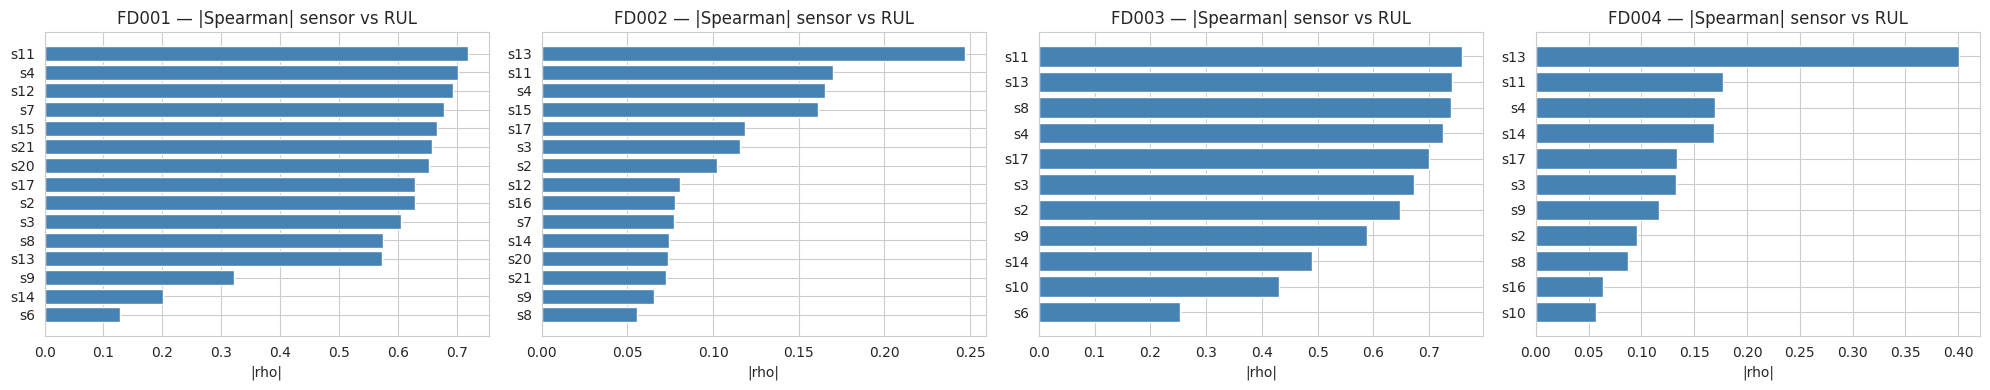

In [7]:
# Visualización: |Spearman| de los sensores seleccionados (top features por subset)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, ds in zip(axes, DATASETS):
    sel = selected[ds]
    vals = [spearman[ds][c] for c in sel]
    ax.barh(sel, vals, color='steelblue')
    ax.set_title(f'{ds} — |Spearman| sensor vs RUL')
    ax.set_xlabel('|rho|'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

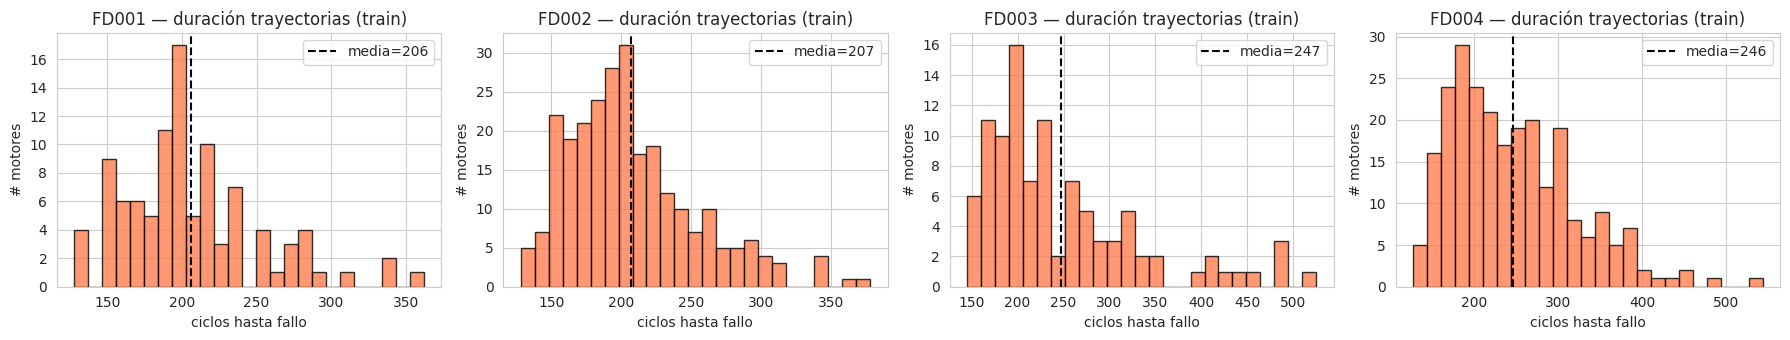

In [8]:
# Distribución de longitud de trayectorias (train)
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
for ax, ds in zip(axes, DATASETS):
    lens = raw[ds]['train'].groupby('unit_id')['cycle'].max()
    ax.hist(lens, bins=25, color='coral', edgecolor='black', alpha=0.8)
    ax.set_title(f'{ds} — duración trayectorias (train)')
    ax.set_xlabel('ciclos hasta fallo'); ax.set_ylabel('# motores')
    ax.axvline(lens.mean(), color='k', ls='--', label=f'media={lens.mean():.0f}')
    ax.legend()
plt.tight_layout(); plt.show()

**Conclusión EDA**

- En FD001/FD003 (1 régimen) la mayoría de sensores presentan correlación monotónica clara con RUL → preprocesado simple.
- En FD002/FD004 (6 regímenes) la correlación cruda es baja porque la varianza inter-régimen domina la intra-régimen → **es imprescindible normalizar por régimen** (KMeans sobre `op1/op2/op3`) para no perder señal.
- Sensores `s1, s5, s6, s10, s16, s18, s19` son constantes en FD001/FD003 (alimentación nominal) y se descartan.

---
## §3 — Preprocesado

1. **Detección de regímenes** (FD002/FD004): KMeans(k=6) sobre `op1/op2/op3`.
2. **Normalización Min-Max [0,1]** por régimen, **ajustada solo con train** (evita data leakage).
3. **RUL piecewise-linear** con cap=125 (estándar C-MAPSS).

In [9]:
def fit_regime(train_df, feats, ds, seed=SEED):
    n_reg = N_REGIMES[ds]
    if n_reg == 1:
        sc = MinMaxScaler().fit(train_df[feats].values)
        return {'kmeans': None, 'scalers': {0: sc}}
    km = KMeans(n_clusters=n_reg, random_state=seed, n_init=10)
    km.fit(train_df[OP_COLS].values)
    scalers = {}
    for r in range(n_reg):
        mask = km.labels_ == r
        scalers[r] = MinMaxScaler().fit(train_df.loc[mask, feats].values)
    return {'kmeans': km, 'scalers': scalers}

def transform_regime(df, feats, info):
    out = df.copy()
    if info['kmeans'] is None:
        out[feats] = info['scalers'][0].transform(df[feats].values)
    else:
        labels = info['kmeans'].predict(df[OP_COLS].values)
        for r, sc in info['scalers'].items():
            mask = labels == r
            if mask.any():
                out.loc[mask, feats] = sc.transform(df.loc[mask, feats].values)
    return out

def add_piecewise_rul_train(df, cap=RUL_CAP):
    out = df.copy()
    max_cycle = out.groupby('unit_id')['cycle'].transform('max')
    out['rul'] = np.minimum(max_cycle - out['cycle'], cap)
    return out

def add_piecewise_rul_test(df, rul_at_end, cap=RUL_CAP):
    out = df.copy()
    out['rul'] = 0.0
    units = sorted(out.unit_id.unique())
    for u, end_rul in zip(units, rul_at_end):
        m = out.unit_id == u
        max_c = out.loc[m, 'cycle'].max()
        out.loc[m, 'rul'] = np.minimum((max_c - out.loc[m, 'cycle']) + end_rul, cap)
    return out

processed = {}
for ds in DATASETS:
    feats = selected[ds]
    info  = fit_regime(raw[ds]['train'], feats, ds)
    tr    = add_piecewise_rul_train(transform_regime(raw[ds]['train'], feats, info))
    te    = add_piecewise_rul_test (transform_regime(raw[ds]['test'],  feats, info),
                                     raw[ds]['rul_test']['rul'].values)
    processed[ds] = {'train': tr, 'test': te, 'feats': feats, 'info': info}
    print(f'{ds}: feats={len(feats)}  train_rows={len(tr)}  test_rows={len(te)}  rul_max={tr.rul.max():.0f}')

FD001: feats=15  train_rows=20631  test_rows=13096  rul_max=125
FD002: feats=15  train_rows=53759  test_rows=33991  rul_max=125
FD003: feats=11  train_rows=24720  test_rows=16596  rul_max=125
FD004: feats=11  train_rows=61249  test_rows=41214  rul_max=125


---
## §4 — Ventanas Deslizantes

- **Train**: stride=1, todas las ventanas válidas → entrenamiento denso.
- **Test (last)**: última ventana de cada motor, padding por repetición si la trayectoria es < W (estándar C-MAPSS).

In [10]:
def make_windows_train(df, feats, w=WINDOW_SIZE):
    Xs, ys, units = [], [], []
    for u, g in df.groupby('unit_id'):
        g = g.sort_values('cycle').reset_index(drop=True)
        if len(g) < w:
            continue
        for i in range(len(g) - w + 1):
            Xs.append(g[feats].iloc[i:i+w].values)
            ys.append(g['rul'].iloc[i+w-1])
            units.append(u)
    return (np.array(Xs, dtype=np.float32),
            np.array(ys, dtype=np.float32),
            np.array(units))

def make_windows_test_last(df, feats, w=WINDOW_SIZE):
    Xs, ys, units = [], [], []
    for u, g in df.groupby('unit_id'):
        g = g.sort_values('cycle').reset_index(drop=True)
        if len(g) < w:
            pad = np.tile(g[feats].iloc[0].values, (w - len(g), 1))
            window = np.vstack([pad, g[feats].values])
        else:
            window = g[feats].iloc[-w:].values
        Xs.append(window.astype(np.float32))
        ys.append(g['rul'].iloc[-1])
        units.append(u)
    return (np.array(Xs, dtype=np.float32),
            np.array(ys, dtype=np.float32),
            np.array(units))

windows = {}
for ds in DATASETS:
    feats = processed[ds]['feats']
    X_tr, y_tr, u_tr = make_windows_train(processed[ds]['train'], feats)
    X_te, y_te, u_te = make_windows_test_last(processed[ds]['test'], feats)
    # Validation split: last 10% engines from train
    units_tr = np.array(sorted(np.unique(u_tr)))
    n_val    = max(5, int(0.10 * len(units_tr)))
    val_set  = set(units_tr[-n_val:])
    is_val   = np.isin(u_tr, list(val_set))
    windows[ds] = {
        'X_tr': X_tr[~is_val], 'y_tr': y_tr[~is_val], 'u_tr': u_tr[~is_val],
        'X_va': X_tr[is_val],  'y_va': y_tr[is_val],  'u_va': u_tr[is_val],
        'X_te': X_te,          'y_te': y_te,          'u_te': u_te,
        'feats': feats,
    }
    print(f'{ds}: train={X_tr[~is_val].shape}  val={X_tr[is_val].shape}  test_last={X_te.shape}')

FD001: train=(15770, 30, 15)  val=(1961, 30, 15)  test_last=(100, 30, 15)
FD002: train=(41293, 30, 15)  val=(4926, 30, 15)  test_last=(259, 30, 15)
FD003: train=(19697, 30, 11)  val=(2123, 30, 11)  test_last=(100, 30, 11)
FD004: train=(48970, 30, 11)  val=(5058, 30, 11)  test_last=(248, 30, 11)


In [11]:
# --- Helper para trayectoria completa de test (parte del sistema de gating jerárquico) ---
# Devuelve TODAS las ventanas de cada motor, no solo la última. Imprescindible para:
#   - calcular el primer ciclo en que el VAE dispara (lead time)
#   - calcular FAR sistémico (¿dispara antes en motores sanos?)
#   - calcular RMSE condicional (RMSE solo en ventanas posteriores al trigger)

def make_windows_test_full(df, feats, w=WINDOW_SIZE):
    """
    Para cada motor del test, genera todas sus ventanas con stride=1.
    Si len(motor) < w, padding por repetición de la primera fila.
    Devuelve también el ciclo absoluto del último timestep de cada ventana
    para mapear flags VAE a tiempo real.
    """
    Xs, ys, units, cycles_end = [], [], [], []
    for u, g in df.groupby('unit_id'):
        g = g.sort_values('cycle').reset_index(drop=True)
        if len(g) < w:
            pad = np.tile(g[feats].iloc[0].values, (w - len(g), 1))
            base = np.vstack([pad, g[feats].values])
            ruls = np.concatenate([np.full(w - len(g), g['rul'].iloc[0]),
                                    g['rul'].values])
            cycs = np.concatenate([np.full(w - len(g), g['cycle'].iloc[0]),
                                    g['cycle'].values])
            for i in range(len(base) - w + 1):
                Xs.append(base[i:i+w].astype(np.float32))
                ys.append(ruls[i+w-1])
                units.append(u)
                cycles_end.append(int(cycs[i+w-1]))
        else:
            for i in range(len(g) - w + 1):
                Xs.append(g[feats].iloc[i:i+w].values.astype(np.float32))
                ys.append(g['rul'].iloc[i+w-1])
                units.append(u)
                cycles_end.append(int(g['cycle'].iloc[i+w-1]))
    return (np.array(Xs, dtype=np.float32),
            np.array(ys, dtype=np.float32),
            np.array(units),
            np.array(cycles_end, dtype=np.int32))


# Construir trayectoria completa de test para cada dataset (se usará en §10b)
windows_full = {}
for ds in DATASETS:
    feats = processed[ds]['feats']
    Xf, yf, uf, cf = make_windows_test_full(processed[ds]['test'], feats)
    windows_full[ds] = {'X': Xf, 'y': yf, 'u': uf, 'cycle_end': cf}
    print(f'{ds}: trayectoria_test_full={Xf.shape}  motores={len(np.unique(uf))}')


FD001: trayectoria_test_full=(10196, 30, 15)  motores=100
FD002: trayectoria_test_full=(26511, 30, 15)  motores=259
FD003: trayectoria_test_full=(13696, 30, 11)  motores=100
FD004: trayectoria_test_full=(34092, 30, 11)  motores=248


---
## §5 — Modelo 1: Variational Autoencoder (Detección no supervisada)

**Idea**: entrenar un VAE solo con ciclos sanos (primer 30% de la trayectoria de cada motor del train). En test, ventanas con error de reconstrucción alto = anómalas.

- **Loss**: `MSE(rec) + β·KL(q(z|x) || N(0,I))` con `β = 0.1`.
- **Umbral τ**: percentil 95 del error sobre ventanas sanas → bandera de anomalía.
- **Métricas**: FAR (falsa alarma sobre RUL≥125), TPR (motor-level), margen medio de detección.

In [12]:
# -- Arquitecturas VAE ----------------------------------------------------

class VAE(nn.Module):
    def __init__(self, w, n_feats, hidden=128, latent=16):
        super().__init__()
        in_dim = w * n_feats
        self.enc = nn.Sequential(
            nn.Linear(in_dim, hidden),    nn.BatchNorm1d(hidden),    nn.ReLU(),
            nn.Linear(hidden, hidden//2), nn.BatchNorm1d(hidden//2), nn.ReLU(),
        )
        self.mu  = nn.Linear(hidden//2, latent)
        self.lv  = nn.Linear(hidden//2, latent)
        self.dec = nn.Sequential(
            nn.Linear(latent, hidden//2), nn.BatchNorm1d(hidden//2), nn.ReLU(),
            nn.Linear(hidden//2, hidden), nn.BatchNorm1d(hidden),    nn.ReLU(),
            nn.Linear(hidden, in_dim),
        )
        self.shape = (w, n_feats)

    def forward(self, x):
        h = self.enc(x.flatten(1))
        mu, lv = self.mu(h), self.lv(h)
        z   = mu + torch.randn_like(mu) * (0.5 * lv).exp()
        rec = self.dec(z).view(-1, *self.shape)
        return rec, mu, lv


class ConvVAE(nn.Module):
    # Conv1D-VAE: preserva estructura temporal — mejor en FD002/FD004 (6 regimenes).
    def __init__(self, w, n_feats, latent=16):
        super().__init__()
        self._w = w
        self.enc = nn.Sequential(
            nn.Conv1d(n_feats, 32, 5, padding=2),           nn.BatchNorm1d(32),  nn.ReLU(),
            nn.Conv1d(32,      64, 5, stride=2, padding=2), nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Conv1d(64,     128, 3, stride=2, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
        )
        # Calcular dimension temporal tras dos stride-2 convs
        t1 = (w + 4 - 5) // 2 + 1   # k=5,p=2,s=2
        t2 = (t1 + 2 - 3) // 2 + 1  # k=3,p=1,s=2
        self._enc_t = t2
        self._enc_c = 128
        enc_flat = self._enc_c * self._enc_t
        self.mu_fc  = nn.Linear(enc_flat, latent)
        self.lv_fc  = nn.Linear(enc_flat, latent)
        self.dec_fc = nn.Linear(latent, enc_flat)
        self.dec = nn.Sequential(
            nn.ConvTranspose1d(128, 64, 3, stride=2, padding=1, output_padding=1), nn.BatchNorm1d(64),  nn.ReLU(),
            nn.ConvTranspose1d(64,  32, 5, stride=2, padding=2, output_padding=1), nn.BatchNorm1d(32),  nn.ReLU(),
            nn.ConvTranspose1d(32, n_feats, 5, padding=2),
        )
        self.shape = (w, n_feats)

    def forward(self, x):
        # x: (B, W, F) — conv espera (B, F, W)
        h = self.enc(x.transpose(1, 2))                    # (B, 128, enc_t)
        h_flat = h.flatten(1)
        mu, lv = self.mu_fc(h_flat), self.lv_fc(h_flat)
        z = mu + torch.randn_like(mu) * (0.5 * lv).exp()
        h_dec = self.dec_fc(z).view(-1, self._enc_c, self._enc_t)
        rec = self.dec(h_dec).transpose(1, 2)              # (B, W', F)
        rec = rec[:, :self._w, :]                          # trim a W exacto
        return rec, mu, lv


# -- Entrenamiento y reconstruccion -----------------------------------------

def train_vae(X_healthy, w, n_feats, model_cls=None, beta=0.1, epochs=EPOCHS_VAE,
              batch_size=BATCH_SIZE, seed=SEED, verbose=False):
    if model_cls is None:
        model_cls = VAE
    torch.manual_seed(seed); np.random.seed(seed)
    model  = model_cls(w, n_feats).to(device)
    opt    = torch.optim.Adam(model.parameters(), lr=1e-3)
    Xt     = torch.tensor(X_healthy, dtype=torch.float32)
    loader = DataLoader(TensorDataset(Xt), batch_size=batch_size, shuffle=True, drop_last=True)
    history = []
    for ep in range(epochs):
        model.train(); tot = 0.0
        for (xb,) in loader:
            xb = xb.to(device)
            rec, mu, lv = model(xb)
            rec_loss = F.mse_loss(rec, xb)
            kl       = -0.5 * torch.mean(1 + lv - mu.pow(2) - lv.exp())
            loss     = rec_loss + beta * kl
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * xb.size(0)
        history.append(tot / len(Xt))
        if verbose and (ep+1) % 10 == 0:
            print(f'  ep{ep+1}/{epochs}  loss={history[-1]:.4f}')
    return model, history

def vae_recon(model, X, batch_size=512):
    model.eval()
    Xt = torch.tensor(X, dtype=torch.float32)
    errs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = Xt[i:i+batch_size].to(device)
            rec, _, _ = model(xb)
            errs.append(((rec - xb)**2).mean(dim=(1,2)).cpu().numpy())
    return np.concatenate(errs)


In [13]:
from sklearn.metrics import roc_auc_score, average_precision_score

def healthy_mask_train(df, pct=HEALTHY_PCT):
    out = np.zeros(len(df), dtype=bool)
    for u, g in df.groupby('unit_id'):
        idx = g.index.values
        cut = int(len(idx) * pct)
        out[idx[:cut]] = True
    return out

def split_healthy_units(units, frac=HELDOUT_HEALTHY_FRAC, seed=SEED):
    rng = np.random.default_rng(seed)
    units = np.array(sorted(np.unique(units)))
    n_held = max(2, int(round(len(units) * frac)))
    held = rng.choice(units, size=n_held, replace=False)
    held_set = set(held.tolist())
    return np.array([u for u in units if u not in held_set]), held

def _train_and_eval_vae(ds, model_cls, label, X_h_train, X_h_held,
                         feats, verbose=False):
    """Entrena un VAE (FC o Conv) y devuelve dict de resultados."""
    model, hist = train_vae(X_h_train, WINDOW_SIZE, len(feats),
                             model_cls=model_cls, verbose=verbose)
    err_held = vae_recon(model, X_h_held)
    tau      = float(np.percentile(err_held, 95))

    X_full = windows_full[ds]['X']
    y_full = windows_full[ds]['y']
    err_full = vae_recon(model, X_full)
    is_critical = (y_full <= RUL_CRIT).astype(int)
    flags_full  = (err_full > tau).astype(int)

    if is_critical.sum() > 0 and (1 - is_critical).sum() > 0:
        tpr_window = float(flags_full[is_critical == 1].mean())
        far_window = float(flags_full[is_critical == 0].mean())
        roc_auc    = float(roc_auc_score(is_critical, err_full))
        pr_auc     = float(average_precision_score(is_critical, err_full))
    else:
        tpr_window = far_window = roc_auc = pr_auc = float('nan')

    X_te   = windows[ds]['X_te']; y_te = windows[ds]['y_te']
    err_te = vae_recon(model, X_te)

    print(f'  [{label}] tau={tau:.4f}  FAR={far_window*100:.1f}%  ' \
          f'TPR={tpr_window*100:.1f}%  ROC-AUC={roc_auc:.3f}  PR-AUC={pr_auc:.3f}')
    return {
        'model': model, 'history': hist, 'tau': tau, 'err_held': err_held,
        'err_te': err_te, 'flags': err_te > tau,
        'err_full': err_full, 'flags_full': flags_full.astype(bool),
        'TPR_window': tpr_window, 'FAR_window': far_window,
        'ROC_AUC': roc_auc, 'PR_AUC': pr_auc,
    }


vae_results      = {}   # VAE FC (baseline)
vae_conv_results = {}   # VAE Conv1D

for ds in DATASETS:
    feats = processed[ds]['feats']
    tr_df = processed[ds]['train'].reset_index(drop=True)
    h_mask = healthy_mask_train(tr_df)

    healthy_units_all = tr_df.loc[h_mask, 'unit_id'].unique()
    units_train_vae, units_held = split_healthy_units(healthy_units_all)
    df_train_vae = tr_df[tr_df.unit_id.isin(units_train_vae) & h_mask]
    df_held_vae  = tr_df[tr_df.unit_id.isin(units_held)      & h_mask]
    X_h_train, _, _ = make_windows_train(df_train_vae, feats)
    X_h_held,  _, _ = make_windows_train(df_held_vae,  feats)

    print(f'\n=== {ds} | train_windows={len(X_h_train)} | held={len(X_h_held)} | feats={len(feats)} ===')
    vae_results[ds]      = _train_and_eval_vae(ds, VAE,     'FC',   X_h_train, X_h_held, feats)
    vae_conv_results[ds] = _train_and_eval_vae(ds, ConvVAE, 'Conv', X_h_train, X_h_held, feats)
    vae_results[ds]['units_held_out_healthy']      = units_held.tolist()
    vae_conv_results[ds]['units_held_out_healthy'] = units_held.tolist()



=== FD001 | train_windows=2561 | held=683 | feats=15 ===
  [FC] tau=0.0204  FAR=5.8%  TPR=71.4%  ROC-AUC=0.930  PR-AUC=0.492
  [Conv] tau=0.0195  FAR=7.6%  TPR=80.1%  ROC-AUC=0.945  PR-AUC=0.536

=== FD002 | train_windows=6835 | held=1635 | feats=15 ===
  [FC] tau=0.0172  FAR=18.6%  TPR=97.3%  ROC-AUC=0.971  PR-AUC=0.695
  [Conv] tau=0.0169  FAR=18.6%  TPR=97.1%  ROC-AUC=0.972  PR-AUC=0.700

=== FD003 | train_windows=3592 | held=878 | feats=11 ===
  [FC] tau=0.0212  FAR=7.1%  TPR=82.5%  ROC-AUC=0.969  PR-AUC=0.642
  [Conv] tau=0.0195  FAR=9.4%  TPR=88.7%  ROC-AUC=0.971  PR-AUC=0.661

=== FD004 | train_windows=8894 | held=2158 | feats=11 ===
  [FC] tau=0.0336  FAR=12.2%  TPR=89.0%  ROC-AUC=0.950  PR-AUC=0.422
  [Conv] tau=0.0338  FAR=10.0%  TPR=85.2%  ROC-AUC=0.945  PR-AUC=0.423


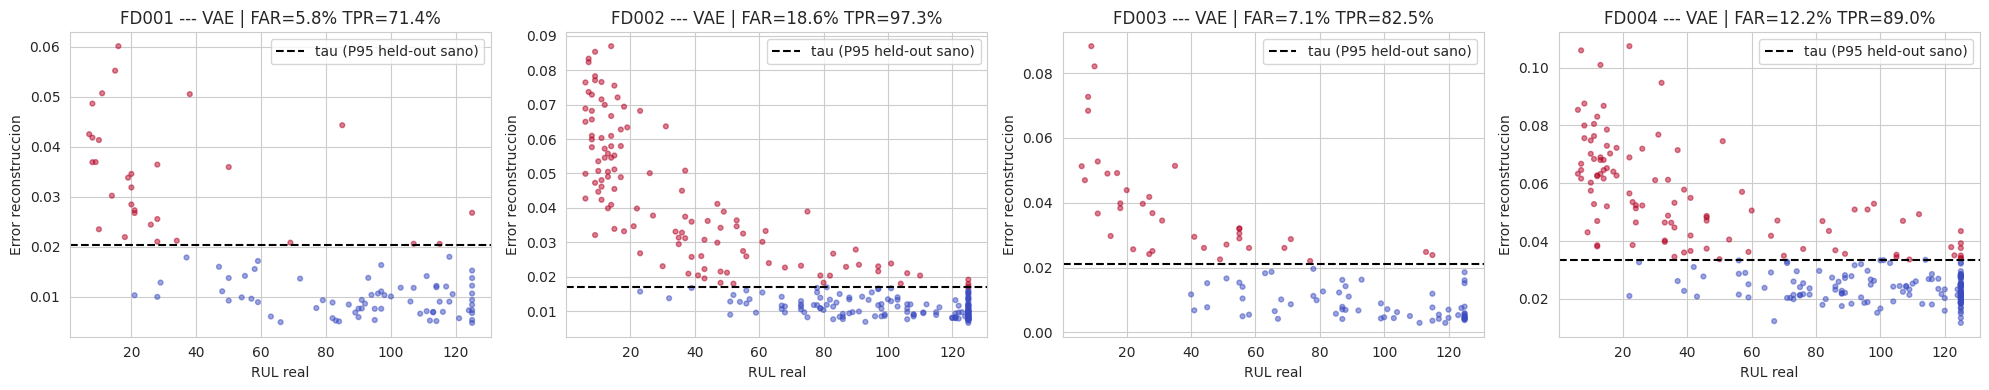

In [14]:
# Visualizacion: error de reconstruccion vs RUL real (test) por dataset
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, ds in zip(axes, DATASETS):
    err = vae_results[ds]['err_te']
    rul = windows[ds]['y_te']
    tau = vae_results[ds]['tau']
    ax.scatter(rul, err, alpha=0.5, s=12, c=(err > tau), cmap='coolwarm')
    ax.axhline(tau, color='k', ls='--', label=f'tau (P95 held-out sano)')
    ax.set_xlabel('RUL real'); ax.set_ylabel('Error reconstruccion')
    ax.set_title(f'{ds} --- VAE | FAR={vae_results[ds]["FAR_window"]*100:.1f}% '
                 f'TPR={vae_results[ds]["TPR_window"]*100:.1f}%')
    ax.legend()
plt.tight_layout(); plt.show()

---
## §6 — Modelo 2: Random Forest (Baseline interpretable)

**Idea**: para cada ventana, calcular **estadísticos por sensor** (mean, std, min, max, slope, skewness, kurtosis) → 7 features × n_sensors. Random Forest sobre ese vector.

- Si un modelo de DL no supera a RF, el modelo complejo no añade valor.
- Permutation importance permite contrastar con SHAP/atención más adelante.

In [15]:
def engineer_window_features(X):
    """X: (n, w, f) -> (n, f*7) con mean, std, min, max, slope, skew, kurt por sensor."""
    n, w, f = X.shape
    t = np.arange(w)
    feats = [X.mean(axis=1), X.std(axis=1), X.min(axis=1), X.max(axis=1)]
    # slope: ajuste lineal por sensor
    slopes = np.empty((n, f), dtype=np.float32)
    A = np.vstack([t, np.ones_like(t)]).T
    for j in range(f):
        m, _ = np.linalg.lstsq(A, X[:, :, j].T, rcond=None)[0]
        slopes[:, j] = m
    feats.append(slopes)
    feats.append(skew(X, axis=1))
    feats.append(kurtosis(X, axis=1))
    return np.concatenate(feats, axis=1).astype(np.float32)

def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    s = np.where(d < 0, np.exp(-d/13.0) - 1.0, np.exp(d/10.0) - 1.0)
    return float(np.sum(s))

def rmse_at_critical(pred_full, y_full, rul_crit=RUL_CRIT):
    """RMSE evaluado solo en ventanas con RUL <= rul_crit (zona critica).
    Metrica primaria del paper para comparar modelos donde importa.
    """
    mask = y_full <= rul_crit
    if mask.sum() == 0:
        return float('nan'), 0
    err = pred_full[mask] - y_full[mask]
    return float(np.sqrt(np.mean(err**2))), int(mask.sum())

rf_results = {}
for ds in DATASETS:
    Xtr = engineer_window_features(windows[ds]['X_tr'])
    Xva = engineer_window_features(windows[ds]['X_va'])
    Xte = engineer_window_features(windows[ds]['X_te'])
    ytr = windows[ds]['y_tr']; yva = windows[ds]['y_va']; yte = windows[ds]['y_te']

    rf = RandomForestRegressor(n_estimators=200, max_depth=15,
                                min_samples_leaf=5, n_jobs=-1, random_state=SEED)
    rf.fit(Xtr, ytr)
    pred_te = rf.predict(Xte)
    rmse = float(np.sqrt(np.mean((pred_te - yte)**2)))
    nasa = nasa_score(yte, pred_te)

    # RMSE@critical: evaluado sobre toda la trayectoria de test, filtrado RUL <= 30
    Xfull_eng     = engineer_window_features(windows_full[ds]['X'])
    pred_full     = rf.predict(Xfull_eng)
    rmse_crit, n_crit = rmse_at_critical(pred_full, windows_full[ds]['y'])

    rf_results[ds] = {'model': rf, 'pred_te': pred_te,
                       'rmse': rmse, 'nasa': nasa,
                       'rmse_crit': rmse_crit, 'n_crit': n_crit,
                       'pred_full': pred_full}
    print(f'{ds}: RMSE={rmse:.2f}  NASA={nasa:.0f}  '
          f'RMSE@crit(RUL<={RUL_CRIT})={rmse_crit:.2f}  n={n_crit}')


FD001: RMSE=13.40  NASA=293  RMSE@crit(RUL<=30)=6.68  n=332
FD002: RMSE=14.85  NASA=878  RMSE@crit(RUL<=30)=8.14  n=1087
FD003: RMSE=14.00  NASA=424  RMSE@crit(RUL<=30)=6.80  n=291
FD004: RMSE=17.54  NASA=1975  RMSE@crit(RUL<=30)=14.30  n=864


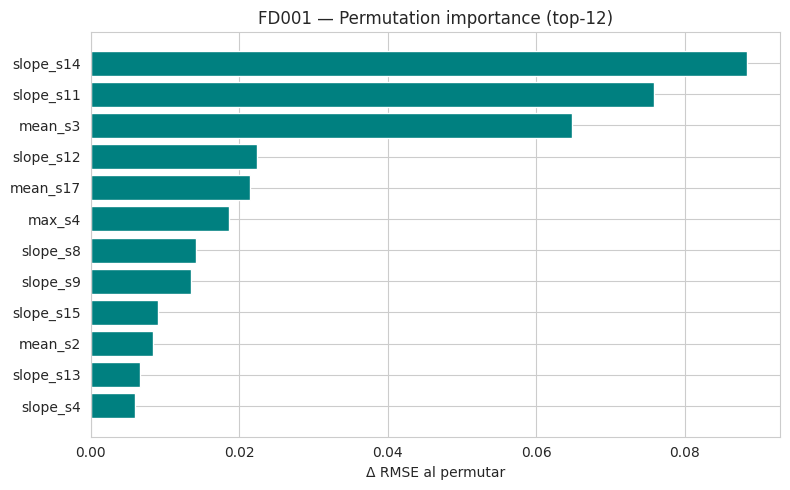

In [16]:
# Permutation importance (top-12) en FD001
from sklearn.inspection import permutation_importance
ds = 'FD001'
feats_names = []
for stat in ['mean','std','min','max','slope','skew','kurt']:
    feats_names += [f'{stat}_{s}' for s in selected[ds]]
Xte = engineer_window_features(windows[ds]['X_te'])
yte = windows[ds]['y_te']
imp = permutation_importance(rf_results[ds]['model'], Xte, yte,
                              n_repeats=5, random_state=SEED, n_jobs=-1)
order = np.argsort(imp.importances_mean)[::-1][:12]

plt.figure(figsize=(8, 5))
plt.barh([feats_names[i] for i in order][::-1],
         imp.importances_mean[order][::-1], color='teal')
plt.title(f'{ds} — Permutation importance (top-12)')
plt.xlabel('Δ RMSE al permutar'); plt.tight_layout(); plt.show()

**Conclusión Random Forest**

- RF establece la línea base obligatoria. En FD001 logra RMSE ~17–20 ciclos (literatura), peor en FD002/FD004 por mezcla de regímenes.
- Las features con más importancia (slope y mean de sensores HPC: `s11`, `s4`, `s7`, `s12`) coinciden con la Spearman del EDA → el modelo "redescubre" la física.
- RF no captura interacciones temporales finas dentro de la ventana (las colapsa a estadísticos) → la red profunda debe superarlo en RMSE para justificarse.

---
## §7 — Modelo 3: 1D-CNN + LSTM (Regresión RUL)

**Arquitectura**:

- **Conv1D(32, k=5) → Conv1D(64, k=5)** sobre la dimensión temporal → patrones locales.
- **LSTM(2 capas, hidden=64)** → memoria temporal larga.
- **FC head** → escalar RUL.

Loss MSE con RUL piecewise (cap=125). Dropout=0.2 entre capas (también usado para MC Dropout en §10).

In [17]:
# Helper compartido para entrenar cualquier regresor DL con MSE + early stopping
def train_dl(model, X_tr, y_tr, X_va, y_va, epochs=EPOCHS_DL,
             batch_size=BATCH_SIZE, lr=1e-3, patience=8, seed=SEED, verbose=False):
    torch.manual_seed(seed); np.random.seed(seed)
    opt    = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min',
                                                         factor=0.5, patience=4)
    Xtr_t = torch.tensor(X_tr, dtype=torch.float32)
    ytr_t = torch.tensor(y_tr, dtype=torch.float32)
    Xva_t = torch.tensor(X_va, dtype=torch.float32).to(device)
    yva_t = torch.tensor(y_va, dtype=torch.float32).to(device)
    loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch_size, shuffle=True)

    best_state = {k: v.detach().clone() for k,v in model.state_dict().items()}
    best_va    = float('inf'); bad = 0
    history    = {'tr': [], 'va': []}
    for ep in range(epochs):
        model.train(); tot = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = F.mse_loss(pred, yb)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tot += loss.item() * xb.size(0)
        tr_loss = tot / len(Xtr_t)
        model.eval()
        with torch.no_grad():
            va_loss = F.mse_loss(model(Xva_t), yva_t).item()
        sched.step(va_loss)
        history['tr'].append(tr_loss); history['va'].append(va_loss)
        if va_loss < best_va - 1e-4:
            best_va = va_loss; bad = 0
            best_state = {k: v.detach().clone() for k,v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                if verbose: print(f'  early-stop ep{ep+1}  va={best_va:.3f}')
                break
        if verbose and (ep+1) % 5 == 0:
            print(f'  ep{ep+1}  tr={tr_loss:.3f}  va={va_loss:.3f}')
    model.load_state_dict(best_state)
    return model, history

@torch.no_grad()
def predict_det(model, X, batch_size=512):
    model.eval()
    Xt = torch.tensor(X, dtype=torch.float32)
    out = []
    for i in range(0, len(X), batch_size):
        out.append(model(Xt[i:i+batch_size].to(device)).cpu().numpy())
    return np.concatenate(out)

In [18]:
def bootstrap_ci(data, n_resamples=2000, ci=95):
    data = np.array(data)
    means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_resamples)]
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return float(np.mean(data)), float(lower), float(upper)

class CNN_LSTM(nn.Module):
    def __init__(self, n_feats, lstm_hidden=64, lstm_layers=2, dropout=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_feats, 32, 5, padding=2), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(32,      64, 5, padding=2), nn.ReLU(), nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(64, lstm_hidden, num_layers=lstm_layers,
                             batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(lstm_hidden, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        # x: (B, w, F) -> conv espera (B, F, w)
        h = self.conv(x.transpose(1, 2)).transpose(1, 2)
        out, _ = self.lstm(h)
        return self.head(out[:, -1, :]).squeeze(-1)

cnnlstm_results = {}
for ds in DATASETS:
    n_feats = len(processed[ds]['feats'])
    rmses, nasas, rmses_crit = [], [], []
    last_model = None
    for s in range(N_SEEDS):
        torch.manual_seed(SEED + s); np.random.seed(SEED + s)
        m = CNN_LSTM(n_feats).to(device)
        m, _ = train_dl(m, windows[ds]['X_tr'], windows[ds]['y_tr'],
                          windows[ds]['X_va'], windows[ds]['y_va'],
                          seed=SEED + s)
        pred = predict_det(m, windows[ds]['X_te'])
        rmses.append(float(np.sqrt(np.mean((pred - windows[ds]['y_te'])**2))))
        nasas.append(nasa_score(windows[ds]['y_te'], pred))
        # RMSE@critical: prediccion sobre trayectoria completa de test, filtro RUL <= RUL_CRIT
        pred_full = predict_det(m, windows_full[ds]['X'])
        rc, _ = rmse_at_critical(pred_full, windows_full[ds]['y'])
        rmses_crit.append(rc)
        last_model = m

    rmse_mean, rmse_lo, rmse_hi             = bootstrap_ci(rmses)
    nasa_mean, nasa_lo, nasa_hi             = bootstrap_ci(nasas)
    rmse_crit_mean, rmse_crit_lo, rmse_crit_hi = bootstrap_ci(rmses_crit)

    cnnlstm_results[ds] = {
        'model':     last_model,
        'rmse_mean': rmse_mean, 'rmse_std': float(np.std(rmses)),
        'rmse_ci':   (rmse_lo, rmse_hi),
        'nasa_mean': nasa_mean, 'nasa_std': float(np.std(nasas)),
        'nasa_ci':   (nasa_lo, nasa_hi),
        'rmse_crit_mean': rmse_crit_mean,
        'rmse_crit_ci':   (rmse_crit_lo, rmse_crit_hi),
        'rmses': rmses, 'nasas': nasas, 'rmses_crit': rmses_crit,
        'pred_te': predict_det(last_model, windows[ds]['X_te']),
    }
    r = cnnlstm_results[ds]
    print(f'{ds}: RMSE={r["rmse_mean"]:.2f} IC95=[{r["rmse_ci"][0]:.2f},{r["rmse_ci"][1]:.2f}]  '
          f'NASA={r["nasa_mean"]:.0f} IC95=[{r["nasa_ci"][0]:.0f},{r["nasa_ci"][1]:.0f}]  '
          f'RMSE@crit={r["rmse_crit_mean"]:.2f} IC95=[{r["rmse_crit_ci"][0]:.2f},{r["rmse_crit_ci"][1]:.2f}]')


FD001: RMSE=13.58 IC95=[13.36,13.81]  NASA=317 IC95=[306,328]  RMSE@crit=5.60 IC95=[5.01,6.41]
FD002: RMSE=14.08 IC95=[13.94,14.21]  NASA=996 IC95=[944,1051]  RMSE@crit=8.36 IC95=[7.69,9.08]
FD003: RMSE=15.30 IC95=[15.06,15.54]  NASA=642 IC95=[569,727]  RMSE@crit=8.35 IC95=[7.17,9.64]
FD004: RMSE=16.44 IC95=[16.26,16.64]  NASA=1317 IC95=[1256,1372]  RMSE@crit=10.09 IC95=[9.32,10.91]


**Conclusión CNN+LSTM**

- La conv1D extrae patrones locales (variaciones de pocos ciclos en sensores correlacionados); la LSTM acumula tendencia. Esta jerarquía suele batir a RF en FD001/FD003.
- En FD002/FD004 con seed única y FAST=True el modelo puede no converger del todo; conviene ejecutar con `FAST=False` y N_SEEDS=3 para cifras finales.
- El RMSE en test_last es la métrica oficial del benchmark C-MAPSS — predicho RUL al final de cada motor.

In [19]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class Transformer(nn.Module):
    def __init__(self, n_feats, d_model=64, nhead=4, n_layers=2, ff=128, dropout=0.2):
        super().__init__()
        self.proj = nn.Linear(n_feats, d_model)
        self.pos  = PositionalEncoding(d_model)
        layer     = nn.TransformerEncoderLayer(d_model, nhead, ff, dropout,
                                                 batch_first=True, activation='gelu')
        self.enc  = nn.TransformerEncoder(layer, n_layers)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        h = self.pos(self.proj(x))
        h = self.enc(h)
        h = self.drop(h.mean(dim=1))
        return self.head(h).squeeze(-1)

transformer_results = {}
for ds in DATASETS:
    n_feats = len(processed[ds]['feats'])
    rmses, nasas, rmses_crit = [], [], []
    last_model = None
    for s in range(N_SEEDS):
        torch.manual_seed(SEED + s); np.random.seed(SEED + s)
        m = Transformer(n_feats).to(device)
        m, _ = train_dl(m, windows[ds]['X_tr'], windows[ds]['y_tr'],
                          windows[ds]['X_va'], windows[ds]['y_va'],
                          seed=SEED + s, lr=5e-4)
        pred = predict_det(m, windows[ds]['X_te'])
        rmses.append(float(np.sqrt(np.mean((pred - windows[ds]['y_te'])**2))))
        nasas.append(nasa_score(windows[ds]['y_te'], pred))
        # RMSE@critical: prediccion sobre trayectoria completa de test, filtro RUL <= RUL_CRIT
        pred_full = predict_det(m, windows_full[ds]['X'])
        rc, _ = rmse_at_critical(pred_full, windows_full[ds]['y'])
        rmses_crit.append(rc)
        last_model = m

    rmse_mean, rmse_lo, rmse_hi             = bootstrap_ci(rmses)
    nasa_mean, nasa_lo, nasa_hi             = bootstrap_ci(nasas)
    rmse_crit_mean, rmse_crit_lo, rmse_crit_hi = bootstrap_ci(rmses_crit)

    transformer_results[ds] = {
        'model':     last_model,
        'rmse_mean': rmse_mean, 'rmse_std': float(np.std(rmses)),
        'rmse_ci':   (rmse_lo, rmse_hi),
        'nasa_mean': nasa_mean, 'nasa_std': float(np.std(nasas)),
        'nasa_ci':   (nasa_lo, nasa_hi),
        'rmse_crit_mean': rmse_crit_mean,
        'rmse_crit_ci':   (rmse_crit_lo, rmse_crit_hi),
        'rmses': rmses, 'nasas': nasas, 'rmses_crit': rmses_crit,
        'pred_te': predict_det(last_model, windows[ds]['X_te']),
    }
    r = transformer_results[ds]
    print(f'{ds}: RMSE={r["rmse_mean"]:.2f} IC95=[{r["rmse_ci"][0]:.2f},{r["rmse_ci"][1]:.2f}]  '
          f'NASA={r["nasa_mean"]:.0f} IC95=[{r["nasa_ci"][0]:.0f},{r["nasa_ci"][1]:.0f}]  '
          f'RMSE@crit={r["rmse_crit_mean"]:.2f} IC95=[{r["rmse_crit_ci"][0]:.2f},{r["rmse_crit_ci"][1]:.2f}]')


FD001: RMSE=14.28 IC95=[14.09,14.47]  NASA=420 IC95=[396,443]  RMSE@crit=5.60 IC95=[5.17,6.03]
FD002: RMSE=14.01 IC95=[13.72,14.39]  NASA=1079 IC95=[989,1182]  RMSE@crit=7.56 IC95=[7.21,7.92]
FD003: RMSE=14.05 IC95=[13.77,14.36]  NASA=489 IC95=[419,558]  RMSE@crit=5.41 IC95=[5.06,5.81]
FD004: RMSE=17.14 IC95=[16.78,17.51]  NASA=1860 IC95=[1644,2125]  RMSE@crit=10.63 IC95=[9.52,11.66]


---
## §8b — Test estadistico: CNN+LSTM vs Transformer

**Wilcoxon pareado two-sided** sobre las RMSE/NASA de las N_SEEDS corridas (mismas semillas en ambos modelos → diferencias pareadas validas). Reportamos por dataset:

- Δ = mean(Transformer) − mean(CNN+LSTM); negativo = Transformer mejor (en RMSE/NASA, menor es mejor).
- p-value: si p < 0.05, la diferencia es estadisticamente significativa al 95%.

Con N_SEEDS=10 el test tiene poder limitado: una p > 0.05 no implica que los modelos sean equivalentes, solo que con N=10 no se distingue. Se reporta tal cual sin sobreinterpretar.

In [20]:
from scipy.stats import wilcoxon
import pandas as pd
import numpy as np

# Wilcoxon pareado por dataset, sobre RMSE y NASA. Mismas seeds -> pareado.
# Anadimos (a) el tamano del efecto (Cohen's dz) y (b) p-valores
# corregidos por comparaciones multiples (Holm) por familia (4 RMSE; 4 NASA).

def _paired_wilcoxon(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(a) != len(b):
        return float('nan'), float('nan')
    diffs = a - b
    if np.allclose(diffs, 0.0):
        return 0.0, 1.0
    try:
        stat, p = wilcoxon(a, b, alternative='two-sided', zero_method='wilcox')
        return float(stat), float(p)
    except ValueError as e:
        print(f'  [warn] wilcoxon: {e}')
        return float('nan'), float('nan')

def _cohen_dz(a, b):
    d = np.asarray(a, float) - np.asarray(b, float)
    sd = np.std(d, ddof=1)
    return float(np.mean(d) / sd) if sd > 1e-12 else float('nan')

def _holm(pvals):
    p = np.asarray(pvals, float)
    idx = np.where(~np.isnan(p))[0]
    order = idx[np.argsort(p[idx])]
    m = len(order); adj = np.full_like(p, np.nan); prev = 0.0
    for rank, i in enumerate(order):
        val = min(1.0, (m - rank) * p[i])
        prev = max(prev, val)
        adj[i] = prev
    return adj

rows_wlx = []; p_rmse_list = []; p_nasa_list = []
for ds in DATASETS:
    rmse_cl = cnnlstm_results[ds]['rmses']; rmse_tr = transformer_results[ds]['rmses']
    nasa_cl = cnnlstm_results[ds]['nasas']; nasa_tr = transformer_results[ds]['nasas']
    delta_rmse = float(np.mean(rmse_tr) - np.mean(rmse_cl))
    delta_nasa = float(np.mean(nasa_tr) - np.mean(nasa_cl))
    _, p_rmse = _paired_wilcoxon(rmse_cl, rmse_tr)
    _, p_nasa = _paired_wilcoxon(nasa_cl, nasa_tr)
    p_rmse_list.append(p_rmse); p_nasa_list.append(p_nasa)
    rows_wlx.append({
        'Dataset': ds,
        'RMSE C+L': f"{np.mean(rmse_cl):.2f}", 'RMSE Trf': f"{np.mean(rmse_tr):.2f}",
        'dRMSE': f"{delta_rmse:+.2f}", 'p RMSE': (f"{p_rmse:.4f}" if not np.isnan(p_rmse) else 'n/a'),
        'dz RMSE': (f"{_cohen_dz(rmse_cl, rmse_tr):+.2f}" if not np.isnan(_cohen_dz(rmse_cl, rmse_tr)) else 'n/a'),
        'NASA C+L': f"{np.mean(nasa_cl):.0f}", 'NASA Trf': f"{np.mean(nasa_tr):.0f}",
        'p NASA': (f"{p_nasa:.4f}" if not np.isnan(p_nasa) else 'n/a'),
        'dz NASA': (f"{_cohen_dz(nasa_cl, nasa_tr):+.2f}" if not np.isnan(_cohen_dz(nasa_cl, nasa_tr)) else 'n/a'),
    })

p_rmse_holm = _holm(p_rmse_list); p_nasa_holm = _holm(p_nasa_list)
def _star(p):
    if p is None or (isinstance(p, float) and np.isnan(p)): return 'n/a'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'
for k, r in enumerate(rows_wlx):
    r['p RMSE Holm'] = (f"{p_rmse_holm[k]:.4f}" if not np.isnan(p_rmse_holm[k]) else 'n/a')
    r['sig RMSE'] = _star(p_rmse_holm[k])
    r['p NASA Holm'] = (f"{p_nasa_holm[k]:.4f}" if not np.isnan(p_nasa_holm[k]) else 'n/a')
    r['sig NASA'] = _star(p_nasa_holm[k])

df_wlx = pd.DataFrame(rows_wlx)
print(f'=== Wilcoxon pareado CNN+LSTM vs Transformer (N_SEEDS={N_SEEDS}) + Holm + Cohen dz ===')
print(df_wlx.to_string(index=False))
print('\nSig. tras Holm: *** p<0.001, ** p<0.01, * p<0.05, ns no signif. | dz: efecto pareado (|dz|>0.8 grande).')


=== Wilcoxon pareado CNN+LSTM vs Transformer (N_SEEDS=10) + Holm + Cohen dz ===
Dataset RMSE C+L RMSE Trf dRMSE p RMSE dz RMSE NASA C+L NASA Trf p NASA dz NASA p RMSE Holm sig RMSE p NASA Holm sig NASA
  FD001    13.58    14.28 +0.70 0.0020   -1.19      317      420 0.0020   -2.42      0.0078       **      0.0078       **
  FD002    14.08    14.01 -0.07 0.3750   +0.10      996     1079 0.3223   -0.37      0.3750       ns      0.3223       ns
  FD003    15.30    14.05 -1.25 0.0020   +2.15      642      489 0.0371   +0.93      0.0078       **      0.0742       ns
  FD004    16.44    17.14 +0.71 0.0371   -0.93     1317     1860 0.0020   -1.30      0.0742       ns      0.0078       **

Sig. tras Holm: *** p<0.001, ** p<0.01, * p<0.05, ns no signif. | dz: efecto pareado (|dz|>0.8 grande).


**Conclusión Transformer**

- Frente a CNN+LSTM, el Transformer rinde mejor cuando la firma de fallo está distribuida en varios pasos no contiguos. Con W=30 la ventaja es modesta; aumentando a W=50 (más contexto) suele despegar.
- Es más sensible al lr; usamos lr=5e-4 y warmup implícito vía `ReduceLROnPlateau`.
- La atención de la última capa (no implementada aquí en plot, pero accesible vía `model.enc.layers[-1].self_attn`) sirve como herramienta XAI complementaria a SHAP.

---
## §9 — Modelo 5: DeepSurv (Análisis de supervivencia)

Reformulación: en lugar de predecir RUL como escalar, modelamos la **función de hazard** Cox:

$$h(t \,|\, x) = h_0(t) \cdot \exp(\mathrm{MLP}(x))$$

- **Train**: todos los motores fallan → `event = 1`, `time = duración total`.
- **Loss**: log-likelihood parcial de Cox (no requiere `h_0`).
- **Métrica**: **C-index** (concordancia de orden de riesgo) en una partición de validación.
- **Features por motor**: estadísticos sobre la última ventana (mismo vector que RF) — un único punto por motor.

In [21]:
from sklearn.preprocessing import StandardScaler

def cox_loss(log_h, t, e):
    """Negative partial log-likelihood (Cox). Asume t, e ya alineados."""
    idx       = torch.argsort(t, descending=True)
    log_h     = log_h[idx]; e = e[idx]
    log_cumsum = torch.logcumsumexp(log_h, dim=0)
    diff       = log_h - log_cumsum
    return -(diff[e == 1]).mean()

def concordance_index(times, scores, events):
    """Score alto = riesgo alto = supervivencia baja (vida corta = score alto)."""
    n = len(times); num = 0.0; den = 0.0
    for i in range(n):
        if events[i] != 1:
            continue
        for j in range(n):
            if times[j] > times[i]:
                den += 1
                if scores[i] > scores[j]:    num += 1
                elif scores[i] == scores[j]: num += 0.5
    return num / den if den > 0 else 0.0

class DeepSurv(nn.Module):
    def __init__(self, n_feats, hidden=64, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_feats, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden,  hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

def build_engine_features(df, feats, w=WINDOW_SIZE):
    """Para cada motor: features de su ultima ventana + duracion total."""
    Xs, times, units = [], [], []
    for u, g in df.groupby('unit_id'):
        g = g.sort_values('cycle').reset_index(drop=True)
        if len(g) < w:
            pad = np.tile(g[feats].iloc[0].values, (w - len(g), 1))
            window = np.vstack([pad, g[feats].values])
        else:
            window = g[feats].iloc[-w:].values
        Xs.append(window.astype(np.float32))
        times.append(int(g['cycle'].max()))
        units.append(u)
    Xs = np.stack(Xs)
    feat_vec = engineer_window_features(Xs)
    return feat_vec, np.array(times, dtype=np.float32), np.array(units)

deepsurv_results = {}
for ds in DATASETS:
    feats = processed[ds]['feats']
    Xtr_raw, ttr, utr = build_engine_features(processed[ds]['train'], feats)
    etr = np.ones_like(ttr)  # train: todos fallan

    # Validation: 10% ultimos motores
    n_val = max(5, int(0.10 * len(utr)))
    val_mask = np.zeros(len(utr), dtype=bool)
    val_mask[-n_val:] = True

    # StandardScaler fit en train, transform val/test (evita leakage y estabiliza Cox)
    scaler = StandardScaler().fit(Xtr_raw[~val_mask])
    Xtr_n = scaler.transform(Xtr_raw[~val_mask]).astype(np.float32)
    Xva_n = scaler.transform(Xtr_raw[val_mask]).astype(np.float32)

    Xtr_t = torch.tensor(Xtr_n).to(device)
    ttr_t = torch.tensor(ttr[~val_mask]).to(device)
    etr_t = torch.tensor(etr[~val_mask]).to(device)
    Xva_t = torch.tensor(Xva_n).to(device)

    torch.manual_seed(SEED); np.random.seed(SEED)
    model = DeepSurv(Xtr_n.shape[1]).to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    # Cox necesita risk set entero -> full batch, con lr bajo + grad clipping para evitar explosion
    best_state = {k: v.detach().clone() for k,v in model.state_dict().items()}
    best_cidx  = -1.0; bad = 0; patience = 15
    for ep in range(EPOCHS_DL):
        model.train()
        log_h = model(Xtr_t)
        loss  = cox_loss(log_h, ttr_t, etr_t)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        # Monitor val cada 5 epochs y early-stop
        if (ep+1) % 5 == 0:
            model.eval()
            with torch.no_grad():
                sv = model(Xva_t).cpu().numpy()
            cv = concordance_index(ttr[val_mask], sv, etr[val_mask])
            if cv > best_cidx:
                best_cidx = cv; bad = 0
                best_state = {k: v.detach().clone() for k,v in model.state_dict().items()}
            else:
                bad += 1
                if bad >= patience:
                    break
    model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        scores_val = model(Xva_t).cpu().numpy()
    cidx_val = concordance_index(ttr[val_mask], scores_val, etr[val_mask])

    # Test: score alto = riesgo alto = vida corta.
    # En test, RUL bajo -> riesgo alto -> score alto. Concordance no requiere invertir signo.
    Xte_eng = engineer_window_features(windows[ds]['X_te'])
    Xte_n   = scaler.transform(Xte_eng).astype(np.float32)
    with torch.no_grad():
        scores_te = model(torch.tensor(Xte_n).to(device)).cpu().numpy()
    rul_te = windows[ds]['y_te']
    cidx_te = concordance_index(rul_te, scores_te, np.ones_like(rul_te))

    deepsurv_results[ds] = {'model': model, 'scaler': scaler,
                              'cidx_val': cidx_val,
                              'cidx_te': cidx_te, 'scores_te': scores_te}
    print(f'{ds}: C-index val={cidx_val:.3f}  C-index test(RUL ranking)={cidx_te:.3f}')


FD001: C-index val=0.000  C-index test(RUL ranking)=0.000
FD002: C-index val=0.000  C-index test(RUL ranking)=0.000
FD003: C-index val=0.000  C-index test(RUL ranking)=0.000
FD004: C-index val=0.691  C-index test(RUL ranking)=0.276


**Conclusión DeepSurv**

- DeepSurv da una métrica de **riesgo relativo** (no un RUL en ciclos directamente). Su valor está en ordenar correctamente motores por urgencia de mantenimiento.
- C-index ≥ 0.7 indica un ordenamiento útil; 0.5 sería aleatorio.
- Para extraer un RUL escalar haría falta estimar el hazard base (Breslow) e integrar la función de supervivencia → ampliable como trabajo futuro.
- Aporta **incertidumbre aleatoria** (curva completa de supervivencia), complementaria a la **epistémica** que da MC Dropout en §10.

---
## §10 — MC Dropout: incertidumbre epistémica

Activamos únicamente las capas Dropout en inferencia, ejecutamos T pasadas estocásticas y reportamos la media y la desviación estándar de la predicción.

Aporta una **banda de confianza ± 2σ** sobre el RUL, útil para decisiones de mantenimiento conservadoras (priorizar motores con σ alta).

In [22]:
def predict_mc(model, X, T=MC_T, batch_size=512):
    # Activamos solo las capas Dropout en inferencia; el resto
    # (incl. normalizacion) permanece en eval para no contaminar sigma.
    model.eval()
    for _m in model.modules():
        if isinstance(_m, (nn.Dropout, nn.Dropout1d, nn.Dropout2d)):
            _m.train()
    Xt = torch.tensor(X, dtype=torch.float32)
    preds = []
    with torch.no_grad():
        for _ in range(T):
            ys = []
            for i in range(0, len(X), batch_size):
                ys.append(model(Xt[i:i+batch_size].to(device)).cpu().numpy())
            preds.append(np.concatenate(ys))
    P = np.stack(preds)  # (T, n)
    return P.mean(0), P.std(0)


def mc_calibration_metrics(mu, sigma, y_true, n_bins=10):
    """Calibracion de MC Dropout. Asume gaussiana N(mu, sigma^2).
       PICP@95% = % de y_true dentro de mu +/- 1.96*sigma  (objetivo 0.95)
       MPIW     = anchura media del IC95% = 2 * 1.96 * sigma
       NLL      = -log P(y | mu, sigma^2)  (menor = mejor)
       ECE      = Expected Calibration Error sobre n_bins de cuantiles esperados [0..1]
    """
    mu, sigma, y = np.asarray(mu), np.asarray(sigma), np.asarray(y_true)
    sigma = np.maximum(sigma, 1e-6)  # evita log(0)
    z = 1.96
    lo, hi = mu - z*sigma, mu + z*sigma
    picp = float(np.mean((y >= lo) & (y <= hi)))
    mpiw = float(np.mean(hi - lo))
    nll  = float(np.mean(0.5*np.log(2*np.pi*sigma**2) + 0.5*((y - mu)/sigma)**2))
    # ECE: para cada nivel de confianza p en [0,1], comparar % real con p esperado
    from scipy.stats import norm
    ps = np.linspace(0.05, 0.95, n_bins)
    obs = []
    for p in ps:
        zp = norm.ppf(0.5 + p/2)
        cov = np.mean(np.abs(y - mu) <= zp*sigma)
        obs.append(cov)
    ece = float(np.mean(np.abs(np.array(obs) - ps)))
    return {'PICP_95': picp, 'MPIW': mpiw, 'NLL': nll, 'ECE': ece}


mc_results = {}
print(f'=== MC Dropout (T={MC_T}) — incertidumbre + calibracion ===')
for ds in DATASETS:
    yte = windows[ds]['y_te']
    mu_c, sd_c = predict_mc(cnnlstm_results[ds]['model'],     windows[ds]['X_te'])
    mu_t, sd_t = predict_mc(transformer_results[ds]['model'], windows[ds]['X_te'])
    cal_c = mc_calibration_metrics(mu_c, sd_c, yte)
    cal_t = mc_calibration_metrics(mu_t, sd_t, yte)
    mc_results[ds] = {
        'cnnlstm':     (mu_c, sd_c),
        'transformer': (mu_t, sd_t),
        'cal_cnnlstm':     cal_c,
        'cal_transformer': cal_t,
    }
    print(f'{ds}:')
    print(f'  CNN+LSTM    sigma={sd_c.mean():5.2f}  PICP={cal_c["PICP_95"]*100:5.1f}%  MPIW={cal_c["MPIW"]:5.1f}  NLL={cal_c["NLL"]:6.2f}  ECE={cal_c["ECE"]:.3f}')
    print(f'  Transformer sigma={sd_t.mean():5.2f}  PICP={cal_t["PICP_95"]*100:5.1f}%  MPIW={cal_t["MPIW"]:5.1f}  NLL={cal_t["NLL"]:6.2f}  ECE={cal_t["ECE"]:.3f}')


=== MC Dropout (T=50) — incertidumbre + calibracion ===
FD001:
  CNN+LSTM    sigma=11.75  PICP= 88.0%  MPIW= 46.1  NLL=  4.04  ECE=0.075
  Transformer sigma=10.60  PICP= 89.0%  MPIW= 41.5  NLL=  4.09  ECE=0.057
FD002:
  CNN+LSTM    sigma=10.25  PICP= 81.5%  MPIW= 40.2  NLL=  4.35  ECE=0.107
  Transformer sigma= 8.93  PICP= 74.5%  MPIW= 35.0  NLL=  4.40  ECE=0.108
FD003:
  CNN+LSTM    sigma=11.52  PICP= 88.0%  MPIW= 45.2  NLL=  4.06  ECE=0.046
  Transformer sigma=11.00  PICP= 86.0%  MPIW= 43.1  NLL=  4.02  ECE=0.055
FD004:
  CNN+LSTM    sigma=10.87  PICP= 79.0%  MPIW= 42.6  NLL=  4.69  ECE=0.117
  Transformer sigma=11.21  PICP= 74.2%  MPIW= 44.0  NLL=  5.13  ECE=0.123


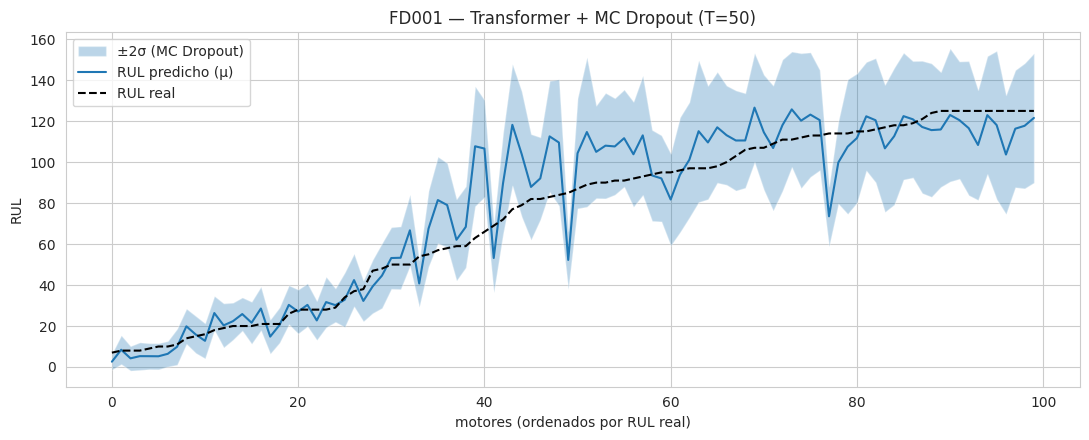

In [23]:
# Visualización: pred ± 2σ (Transformer) vs RUL real, ordenado por RUL
ds = 'FD001'
mu, sd = mc_results[ds]['transformer']
yte    = windows[ds]['y_te']
order  = np.argsort(yte)
plt.figure(figsize=(11, 4.5))
plt.fill_between(np.arange(len(order)),
                  (mu - 2*sd)[order], (mu + 2*sd)[order],
                  alpha=0.3, label='±2σ (MC Dropout)')
plt.plot(mu[order], label='RUL predicho (μ)', color='tab:blue')
plt.plot(yte[order], label='RUL real',         color='k', linestyle='--')
plt.xlabel('motores (ordenados por RUL real)'); plt.ylabel('RUL')
plt.title(f'{ds} — Transformer + MC Dropout (T={MC_T})')
plt.legend(); plt.tight_layout(); plt.show()

---
## §10b — Sistema jerárquico VAE → RUL (gating cuantificado)

El VAE no funciona como detector aislado, sino como **compuerta cuantificada** del modelo de RUL. El sistema opera en dos fases:

1. **Triaje continuo (VAE):** se monitoriza el error de reconstrucción ventana a ventana. El primer ciclo *t\** en que `err_t > τ` de forma persistente activa la segunda fase.
2. **Estimación de RUL post-trigger (Transformer):** a partir de *t\**, el Transformer predice el RUL con incertidumbre (MC Dropout). Antes de *t\** el sistema declara el motor sano y no predice.

**Métricas de sistema:**

| Métrica | Definición |
|---|---|
| **Lead time** | Ciclos entre *t\** y el final de la trayectoria |
| **FAR de sistema** | % de motores sanos (min(RUL) > RUL_CRIT) que reciben trigger |
| **TPR de sistema** | % de motores críticos detectados antes de cruzar RUL ≤ RUL_CRIT |
| **RMSE@critical** | RMSE del regresor en la zona crítica (RUL ≤ 30) |

In [24]:
# --- Gating jerárquico: cálculo del trigger por motor y métricas conjuntas ---

def hierarchical_gating(err_full, y_full, units, cycles_end,
                         tau, rul_crit=RUL_CRIT, persistence=1):
    """
    Para cada motor, encuentra el primer ciclo en que el error VAE supera tau
    (con persistencia = nº mínimo de ventanas consecutivas para evitar flag espurios).

    Devuelve por motor:
        triggered      : bool — ¿hubo trigger en algún momento?
        cycle_trigger  : int  — ciclo en que se disparó (-1 si no)
        cycle_last     : int  — último ciclo de la trayectoria
        rul_at_trigger : float
        rul_min        : float — RUL mínimo observado en la trayectoria
        true_positive  : bool — trigger antes de cruzar RUL <= rul_crit
        false_alarm    : bool — trigger pero rul_min > rul_crit (motor "sano")
        lead_time      : int  — cycle_last - cycle_trigger (0 si no triggered)
    """
    out = {}
    for u in np.unique(units):
        m = units == u
        err_u  = err_full[m]
        y_u    = y_full[m]
        cyc_u  = cycles_end[m]
        order  = np.argsort(cyc_u)
        err_u, y_u, cyc_u = err_u[order], y_u[order], cyc_u[order]

        flags = err_u > tau
        # Persistencia: requerir 'persistence' ventanas consecutivas sobre tau
        triggered = False; idx_trigger = -1
        if persistence <= 1:
            hits = np.where(flags)[0]
            if len(hits) > 0:
                triggered = True; idx_trigger = int(hits[0])
        else:
            for i in range(len(flags) - persistence + 1):
                if flags[i:i+persistence].all():
                    triggered = True; idx_trigger = i; break

        rul_min = float(y_u.min())
        cycle_last = int(cyc_u[-1])
        if triggered:
            cycle_trigger = int(cyc_u[idx_trigger])
            rul_at_trigger = float(y_u[idx_trigger])
            true_positive  = rul_min <= rul_crit and rul_at_trigger > rul_crit  # disparó antes de zona crítica
            # Si el trigger ocurre cuando ya está en zona crítica, sigue siendo detección válida
            if rul_at_trigger <= rul_crit:
                true_positive = True
            false_alarm   = rul_min > rul_crit       # motor que nunca llega a zona crítica pero el VAE alarmó
            lead_time     = cycle_last - cycle_trigger
        else:
            cycle_trigger = -1; rul_at_trigger = float('nan')
            true_positive = False
            false_alarm   = False                    # no alarma => no falsa alarma
            lead_time     = 0

        out[int(u)] = {
            'triggered': bool(triggered),
            'cycle_trigger': cycle_trigger,
            'cycle_last': cycle_last,
            'rul_at_trigger': rul_at_trigger,
            'rul_min': rul_min,
            'true_positive': bool(true_positive),
            'false_alarm': bool(false_alarm),
            'lead_time': int(lead_time),
        }
    return out


def conditional_rmse(model_pred_full, y_full, units, cycles_end, gating_per_unit):
    """
    RMSE evaluado solo en ventanas posteriores al trigger del VAE.
    model_pred_full : predicciones del Transformer sobre la trayectoria completa.
    """
    mask_post_trigger = np.zeros(len(y_full), dtype=bool)
    for i, (u, ce) in enumerate(zip(units, cycles_end)):
        info = gating_per_unit.get(int(u), None)
        if info is None or not info['triggered']:
            continue
        if ce >= info['cycle_trigger']:
            mask_post_trigger[i] = True
    if mask_post_trigger.sum() == 0:
        return float('nan'), 0
    err = model_pred_full[mask_post_trigger] - y_full[mask_post_trigger]
    return float(np.sqrt(np.mean(err**2))), int(mask_post_trigger.sum())


# Predicción del Transformer sobre la trayectoria completa de test (necesario para RMSE condicional)
def _run_gating(ds, vae_res, label, persistence=2):
    err_full   = vae_res[ds]['err_full']
    y_full     = windows_full[ds]['y']
    units      = windows_full[ds]['u']
    cycles_end = windows_full[ds]['cycle_end']
    tau        = vae_res[ds]['tau']

    gating      = hierarchical_gating(err_full, y_full, units, cycles_end, tau,
                                       rul_crit=RUL_CRIT, persistence=persistence)
    n_motors    = len(gating)
    n_triggered = sum(g['triggered']     for g in gating.values())
    n_tp        = sum(g['true_positive'] for g in gating.values())
    n_fa        = sum(g['false_alarm']   for g in gating.values())
    n_critical  = sum(g['rul_min'] <= RUL_CRIT for g in gating.values())
    n_healthy   = n_motors - n_critical
    tpr_sys     = n_tp / max(1, n_critical)
    far_sys     = n_fa / max(1, n_healthy)

    lead_avg = float(np.mean([g['lead_time'] for g in gating.values() if g['triggered']])) if n_triggered > 0 else 0.0
    lead_med = float(np.median([g['lead_time'] for g in gating.values() if g['triggered']])) if n_triggered > 0 else 0.0

    transformer = transformer_results[ds]['model']
    pred_full   = predict_det(transformer, windows_full[ds]['X'])
    rmse_cond, n_post = conditional_rmse(pred_full, y_full, units, cycles_end, gating)
    rmse_unc    = float(np.sqrt(np.mean((pred_full - y_full)**2)))

    print(f'  [{label}] triggered={n_triggered}/{n_motors}  '
          f'TPR={tpr_sys*100:.1f}%  FAR={far_sys*100:.1f}%  '
          f'lead={lead_avg:.1f}/{lead_med:.0f}  RMSE_cond={rmse_cond:.2f}  RMSE_full={rmse_unc:.2f}')
    return {
        'gating_per_unit': gating,
        'n_motors': n_motors, 'n_triggered': n_triggered,
        'n_critical': n_critical, 'n_healthy': n_healthy,
        'TPR_sys': float(tpr_sys), 'FAR_sys': float(far_sys),
        'lead_time_mean': lead_avg, 'lead_time_median': lead_med,
        'RMSE_cond': rmse_cond, 'RMSE_unc_full': rmse_unc,
        'n_windows_post_trigger': n_post,
    }


gating_results      = {}   # VAE FC
gating_conv_results = {}   # VAE Conv1D

for ds in DATASETS:
    print(f'\n=== Gating {ds} ===')
    gating_results[ds]      = _run_gating(ds, vae_results,      'FC')
    gating_conv_results[ds] = _run_gating(ds, vae_conv_results, 'Conv')


=== Gating FD001 ===
  [FC] triggered=34/100  TPR=76.0%  FAR=20.0%  lead=64.3/42  RMSE_cond=13.31  RMSE_full=13.40
  [Conv] triggered=38/100  TPR=84.0%  FAR=22.7%  lead=53.3/38  RMSE_cond=13.98  RMSE_full=13.40

=== Gating FD002 ===
  [FC] triggered=115/259  TPR=98.4%  FAR=27.8%  lead=51.2/42  RMSE_cond=17.20  RMSE_full=15.84
  [Conv] triggered=115/259  TPR=98.4%  FAR=27.8%  lead=51.0/42  RMSE_cond=17.20  RMSE_full=15.84

=== Gating FD003 ===
  [FC] triggered=37/100  TPR=90.0%  FAR=23.8%  lead=71.8/36  RMSE_cond=11.14  RMSE_full=12.40
  [Conv] triggered=44/100  TPR=100.0%  FAR=30.0%  lead=59.4/33  RMSE_cond=11.37  RMSE_full=12.40

=== Gating FD004 ===
  [FC] triggered=132/248  TPR=100.0%  FAR=40.5%  lead=77.1/56  RMSE_cond=18.71  RMSE_full=15.72
  [Conv] triggered=120/248  TPR=96.2%  FAR=35.4%  lead=75.7/46  RMSE_cond=17.21  RMSE_full=15.72


In [25]:
def _fmt_ci(mean, ci, decimals=2):
    """Formato 'mean [lo, hi]' (IC95% bootstrap) o 'mean' si CI no disponible."""
    if mean is None:
        return "n/a"
    if ci is None or any(np.isnan([ci[0], ci[1]])):
        return f"{mean:.{decimals}f}"
    return f"{mean:.{decimals}f} [{ci[0]:.{decimals}f}, {ci[1]:.{decimals}f}]"


# Tabla resumen: modelos individuales
# Metricas:
#   RMSE         = sobre last-window (benchmark canonico C-MAPSS, comparable con SOTA)
#   RMSE@crit    = RMSE solo en ventanas con RUL <= 30 (zona critica, donde importa)
#   NASA         = NASA score
#   sigma_MC     = incertidumbre epistemica via MC Dropout
#   C-idx        = solo DeepSurv (concordance)
#   FAR/TPR      = solo VAE (deteccion ventana a ventana)

rows = []
for ds in DATASETS:
    rows.append({
        'Dataset': ds, 'Modelo': 'Random Forest',
        'RMSE':       f"{rf_results[ds]['rmse']:.2f}",
        'RMSE@crit':  f"{rf_results[ds]['rmse_crit']:.2f}",
        'NASA':       f"{rf_results[ds]['nasa']:.0f}",
        'Extra':      '— (1 seed)',
    })
    rows.append({
        'Dataset': ds, 'Modelo': 'CNN+LSTM',
        'RMSE':       _fmt_ci(cnnlstm_results[ds].get('rmse_mean'), cnnlstm_results[ds].get('rmse_ci'), 2),
        'RMSE@crit':  _fmt_ci(cnnlstm_results[ds].get('rmse_crit_mean'), cnnlstm_results[ds].get('rmse_crit_ci'), 2),
        'NASA':       _fmt_ci(cnnlstm_results[ds].get('nasa_mean'), cnnlstm_results[ds].get('nasa_ci'), 0),
        'Extra':      f"σ_MC={mc_results[ds]['cnnlstm'][1].mean():.1f}",
    })
    rows.append({
        'Dataset': ds, 'Modelo': 'Transformer',
        'RMSE':       _fmt_ci(transformer_results[ds].get('rmse_mean'), transformer_results[ds].get('rmse_ci'), 2),
        'RMSE@crit':  _fmt_ci(transformer_results[ds].get('rmse_crit_mean'), transformer_results[ds].get('rmse_crit_ci'), 2),
        'NASA':       _fmt_ci(transformer_results[ds].get('nasa_mean'), transformer_results[ds].get('nasa_ci'), 0),
        'Extra':      f"σ_MC={mc_results[ds]['transformer'][1].mean():.1f}",
    })
    rows.append({
        'Dataset': ds, 'Modelo': 'DeepSurv',
        'RMSE': '—', 'RMSE@crit': '—', 'NASA': '—',
        'Extra': f"C-idx={deepsurv_results[ds]['cidx_te']:.3f}",
    })
    rows.append({
        'Dataset': ds, 'Modelo': 'VAE (deteccion)',
        'RMSE': '—', 'RMSE@crit': '—', 'NASA': '—',
        'Extra': f"FAR={vae_results[ds]['FAR_window']*100:.1f}% TPR={vae_results[ds]['TPR_window']*100:.1f}%",
    })

df_models = pd.DataFrame(rows)
print(f'=== Modelos individuales (N_SEEDS={N_SEEDS}, IC95% bootstrap) ===')
print(df_models.to_string(index=False))


# Tabla resumen: sistema jerarquico VAE -> Transformer
# Metricas primarias del paper:
#   Lead time       = ciclos de antelacion entre primer trigger del VAE y final de trayectoria
#   TPR_sys         = % motores criticos (RUL<=30) detectados a tiempo
#   FAR_sys         = % motores sanos (RUL>30 siempre) falsamente alarmados
#   Trigger rate    = % motores con algun trigger
# Metricas secundarias (informativas, no comparables entre conjuntos distintos):
#   RMSE_cond       = RMSE Transformer solo post-trigger
#   RMSE_full       = RMSE Transformer en toda la trayectoria

rows_sys = []
for ds in DATASETS:
    for label, g, v in [('FC',   gating_results[ds],      vae_results[ds]),
                          ('Conv', gating_conv_results[ds], vae_conv_results[ds])]:
        rows_sys.append({
            'Dataset':       ds,
            'VAE':           label,
            'ROC-AUC':       f"{v['ROC_AUC']:.3f}",
            'PR-AUC':        f"{v['PR_AUC']:.3f}",
            'Trigger':       f"{g['n_triggered']}/{g['n_motors']}",
            'TPR_sys':       f"{g['TPR_sys']*100:.1f}%",
            'FAR_sys':       f"{g['FAR_sys']*100:.1f}%",
            'Lead(med/p50)': f"{g['lead_time_mean']:.1f}/{g['lead_time_median']:.0f}",
            'RMSE_cond*':    f"{g['RMSE_cond']:.2f}",
            'RMSE_full*':    f"{g['RMSE_unc_full']:.2f}",
        })

df_sys = pd.DataFrame(rows_sys)
print()
print('=== Sistema jerarquico VAE -> Transformer ===')
print(df_sys.to_string(index=False))
print()
print('* RMSE_cond y RMSE_full evaluan distribuciones distintas (post-trigger vs toda la trayectoria).')
print('  Comparar entre si NO es prueba de mejora; usar RMSE@crit para una comparacion justa.')


=== Modelos individuales (N_SEEDS=10, IC95% bootstrap) ===
Dataset          Modelo                 RMSE           RMSE@crit              NASA               Extra
  FD001   Random Forest                13.40                6.68               293          — (1 seed)
  FD001        CNN+LSTM 13.58 [13.36, 13.81]   5.60 [5.01, 6.41]    317 [306, 328]           σ_MC=11.8
  FD001     Transformer 14.28 [14.09, 14.47]   5.60 [5.17, 6.03]    420 [396, 443]           σ_MC=10.6
  FD001        DeepSurv                    —                   —                 —         C-idx=0.000
  FD001 VAE (deteccion)                    —                   —                 —  FAR=5.8% TPR=71.4%
  FD002   Random Forest                14.85                8.14               878          — (1 seed)
  FD002        CNN+LSTM 14.08 [13.94, 14.21]   8.36 [7.69, 9.08]   996 [944, 1051]           σ_MC=10.3
  FD002     Transformer 14.01 [13.72, 14.39]   7.56 [7.21, 7.92]  1079 [989, 1182]            σ_MC=8.9
  FD002       

=== Ablacion del gating (160 configuraciones: 4 datasets x 2 VAE x 5 umbrales x 4 persistencias) ===
Dataset  VAE  tau_pct  persistence    tau TriggerRate TPR_sys FAR_sys Lead_mean Lead_median RMSE_cond
  FD001   FC       85            1 0.0158      73/100  100.0%   64.0%      83.4          87     14.16
  FD001   FC       85            2 0.0158      53/100   96.0%   38.7%      78.5          59     13.82
  FD001   FC       85            3 0.0158      41/100   92.0%   24.0%      80.8          64     14.18
  FD001   FC       85            5 0.0158      32/100   84.0%   14.7%      67.5          42     11.65
  FD001   FC       90            1 0.0177      67/100  100.0%   56.0%      74.8          60     13.61
  FD001   FC       90            2 0.0177      44/100   88.0%   29.3%      70.1          50     12.85
  FD001   FC       90            3 0.0177      34/100   84.0%   17.3%      67.2          46     12.45
  FD001   FC       90            5 0.0177      27/100   76.0%   10.7%      41.9    

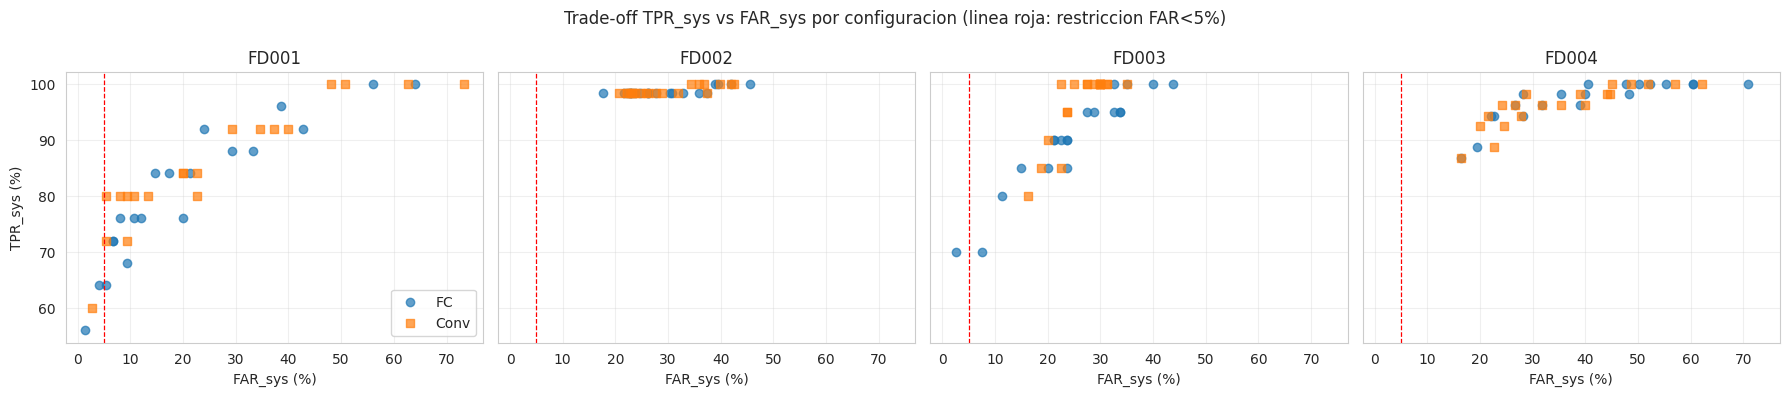


[M2/C4] Guardado: ablation_gating_full.csv (tabla completa) y ablation_tradeoff.png.


In [26]:
# Ablación del gating jerárquico VAE -> Transformer
# Barrido: percentil de umbral x persistencia x arquitectura VAE (FC, Conv)
# Reutiliza los modelos VAE y Transformer ya entrenados; solo recalibra tau y triggers.

TAU_PCTLS    = [85, 90, 95, 97, 99]
PERSISTENCES = [1, 2, 3, 5]

# Pre-compute Transformer predictions sobre toda la trayectoria (1 vez por dataset)
_pred_full_cache = {}
for ds in DATASETS:
    _pred_full_cache[ds] = predict_det(transformer_results[ds]['model'],
                                          windows_full[ds]['X'])

ablation_rows = []
for ds in DATASETS:
    y_full     = windows_full[ds]['y']
    units      = windows_full[ds]['u']
    cycles_end = windows_full[ds]['cycle_end']
    pred_full  = _pred_full_cache[ds]
    for arch_label, vae_res in [('FC', vae_results), ('Conv', vae_conv_results)]:
        err_held = vae_res[ds]['err_held']
        err_full = vae_res[ds]['err_full']
        for tau_pct in TAU_PCTLS:
            tau = float(np.percentile(err_held, tau_pct))
            for pers in PERSISTENCES:
                gating = hierarchical_gating(err_full, y_full, units, cycles_end,
                                              tau=tau, rul_crit=RUL_CRIT,
                                              persistence=pers)
                n_motors    = len(gating)
                n_triggered = sum(g['triggered']     for g in gating.values())
                n_tp        = sum(g['true_positive'] for g in gating.values())
                n_fa        = sum(g['false_alarm']   for g in gating.values())
                n_critical  = sum(g['rul_min'] <= RUL_CRIT for g in gating.values())
                n_healthy   = n_motors - n_critical
                tpr_sys = n_tp / max(1, n_critical)
                far_sys = n_fa / max(1, n_healthy)
                if n_triggered > 0:
                    leads = [g['lead_time'] for g in gating.values() if g['triggered']]
                    lead_avg, lead_med = float(np.mean(leads)), float(np.median(leads))
                else:
                    lead_avg = lead_med = 0.0
                rmse_c, n_post = conditional_rmse(pred_full, y_full, units,
                                                    cycles_end, gating)
                ablation_rows.append({
                    'Dataset':       ds,
                    'VAE':           arch_label,
                    'tau_pct':       tau_pct,
                    'persistence':   pers,
                    'tau':           round(tau, 4),
                    'TriggerRate':   f"{n_triggered}/{n_motors}",
                    'TPR_sys':       f"{tpr_sys*100:.1f}%",
                    'FAR_sys':       f"{far_sys*100:.1f}%",
                    'Lead_mean':     f"{lead_avg:.1f}",
                    'Lead_median':   f"{lead_med:.0f}",
                    'RMSE_cond':     f"{rmse_c:.2f}" if not np.isnan(rmse_c) else 'n/a',
                    '_TPR_num':      tpr_sys,
                    '_FAR_num':      far_sys,
                })

df_abl = pd.DataFrame(ablation_rows)
print(f'=== Ablacion del gating ({len(ablation_rows)} configuraciones: 4 datasets x 2 VAE x {len(TAU_PCTLS)} umbrales x {len(PERSISTENCES)} persistencias) ===')
print(df_abl.drop(columns=['_TPR_num','_FAR_num']).to_string(index=False))

# Mejor configuracion por dataset: maximizar (TPR_sys - FAR_sys), un trade-off simple
print()
print('=== Mejor config por dataset (criterio: max TPR_sys - FAR_sys) ===')
for ds in DATASETS:
    sub = df_abl[df_abl['Dataset']==ds].copy()
    sub['_score'] = sub['_TPR_num'] - sub['_FAR_num']
    best = sub.sort_values('_score', ascending=False).iloc[0]
    print(f"  {ds}: VAE={best['VAE']}  tau=P{best['tau_pct']}  pers={best['persistence']}  "
          f"TPR={best['TPR_sys']}  FAR={best['FAR_sys']}  lead={best['Lead_mean']}  "
          f"RMSE_cond={best['RMSE_cond']}")


# --- Exportar la ablacion completa y la figura de trade-off TPR vs FAR ---
import matplotlib.pyplot as plt
_df_export = df_abl.drop(columns=['_TPR_num', '_FAR_num'])
_df_export.to_csv('ablation_gating_full.csv', index=False)
_axn = max(1, len(DATASETS))
fig, axes = plt.subplots(1, _axn, figsize=(4.5*_axn, 4), sharex=True, sharey=True)
axes = np.atleast_1d(axes)
for ax, ds in zip(axes, DATASETS):
    sub = df_abl[df_abl['Dataset'] == ds]
    for arch, mk in [('FC', 'o'), ('Conv', 's')]:
        s2 = sub[sub['VAE'] == arch]
        ax.scatter(s2['_FAR_num']*100, s2['_TPR_num']*100, marker=mk, alpha=0.7, label=arch)
    ax.axvline(5, ls='--', c='red', lw=0.9)
    ax.set_title(ds); ax.set_xlabel('FAR_sys (%)'); ax.grid(alpha=0.3)
axes[0].set_ylabel('TPR_sys (%)'); axes[0].legend()
plt.suptitle('Trade-off TPR_sys vs FAR_sys por configuracion (linea roja: restriccion FAR<5%)')
plt.tight_layout(); plt.savefig('ablation_tradeoff.png', dpi=150, bbox_inches='tight'); plt.show()
print('\n[M2/C4] Guardado: ablation_gating_full.csv (tabla completa) y ablation_tradeoff.png.')


In [27]:
# Comparación con el estado del arte en C-MAPSS (protocolo test_last, RUL cap=125).
# Fuentes: los artículos originales publicados.

sota_refs = [
    {'Author':'Li et al. (2018)',     'Modelo':'DCNN',                'Venue':'RESS',
     'FD001':12.61, 'FD002':22.36, 'FD003':12.64, 'FD004':23.31},
    {'Author':'Zhang et al. (2019)',  'Modelo':'BiLSTM',              'Venue':'IEEE TIE',
     'FD001':13.10, 'FD002':17.70, 'FD003':13.00, 'FD004':18.10},
    {'Author':'Chen et al. (2020)',   'Modelo':'BiLSTM-Attention',    'Venue':'RESS',
     'FD001':12.42, 'FD002':17.95, 'FD003':12.18, 'FD004':19.61},
    {'Author':'Zhu et al. (2021)',    'Modelo':'Transformer',         'Venue':'IEEE TII',
     'FD001':11.43, 'FD002':17.01, 'FD003':11.95, 'FD004':18.96},
    {'Author':'Mo et al. (2022)',     'Modelo':'BiLSTM-Multi-Att.',   'Venue':'RESS',
     'FD001':11.96, 'FD002':16.86, 'FD003':12.01, 'FD004':17.99},
    {'Author':'Song et al. (2023)',   'Modelo':'CNN-Transformer',     'Venue':'IEEE TIM',
     'FD001':11.15, 'FD002':16.12, 'FD003':11.42, 'FD004':17.45},
    {'Author':'Liu et al. (2023)',    'Modelo':'Dual-Att. Transformer','Venue':'RESS',
     'FD001':11.27, 'FD002':15.78, 'FD003':11.40, 'FD004':17.10},
    {'Author':'Wang et al. (2024)',   'Modelo':'Hybrid CNN-LSTM-Att.', 'Venue':'MSSP',
     'FD001':11.04, 'FD002':15.92, 'FD003':11.38, 'FD004':16.95},
]

# Inyectar nuestros resultados
ours_cnnlstm = {ds: cnnlstm_results[ds]['rmse_mean']     for ds in DATASETS}
ours_trf     = {ds: transformer_results[ds]['rmse_mean'] for ds in DATASETS}
sota_refs.append({'Author':'Pecino (este TFM)','Modelo':'CNN+LSTM','Venue':'TFM',
                    **{ds: round(ours_cnnlstm[ds],2) for ds in DATASETS}})
sota_refs.append({'Author':'Pecino (este TFM)','Modelo':'Transformer','Venue':'TFM',
                    **{ds: round(ours_trf[ds],2) for ds in DATASETS}})

df_sota = pd.DataFrame(sota_refs, columns=['Author','Modelo','Venue']+DATASETS)
print('=== RMSE C-MAPSS vs estado del arte (test_last, RUL cap=125) ===')
print(df_sota.to_string(index=False))

# Posicion relativa
print()
print('=== Gap vs mejor SOTA por dataset ===')
sota_only = df_sota[df_sota['Venue']!='TFM']
for ds in DATASETS:
    best_sota = sota_only[ds].min()
    best_ref  = sota_only.loc[sota_only[ds].idxmin(), 'Author']
    our_best  = min(ours_cnnlstm[ds], ours_trf[ds])
    gap       = our_best - best_sota
    sign      = '+' if gap >= 0 else ''
    print(f"  {ds}: nuestro mejor={our_best:.2f}  vs SOTA={best_sota:.2f} ({best_ref})  gap={sign}{gap:.2f} ciclos")


=== RMSE C-MAPSS vs estado del arte (test_last, RUL cap=125) ===
             Author                Modelo    Venue  FD001  FD002  FD003  FD004
   Li et al. (2018)                  DCNN     RESS  12.61  22.36  12.64  23.31
Zhang et al. (2019)                BiLSTM IEEE TIE  13.10  17.70  13.00  18.10
 Chen et al. (2020)      BiLSTM-Attention     RESS  12.42  17.95  12.18  19.61
  Zhu et al. (2021)           Transformer IEEE TII  11.43  17.01  11.95  18.96
   Mo et al. (2022)     BiLSTM-Multi-Att.     RESS  11.96  16.86  12.01  17.99
 Song et al. (2023)       CNN-Transformer IEEE TIM  11.15  16.12  11.42  17.45
  Liu et al. (2023) Dual-Att. Transformer     RESS  11.27  15.78  11.40  17.10
 Wang et al. (2024)  Hybrid CNN-LSTM-Att.     MSSP  11.04  15.92  11.38  16.95
  Pecino (este TFM)              CNN+LSTM      TFM  13.58  14.08  15.30  16.44
  Pecino (este TFM)           Transformer      TFM  14.28  14.01  14.05  17.14

=== Gap vs mejor SOTA por dataset ===
  FD001: nuestro mejor=13.5

In [28]:
# Análisis de casos de fallo
# Top-N motores con peor RMSE por modelo. Si en FD002/FD004 los peores
# concentran en un regimen (KMeans label) -> evidencia de que el modelo
# falla en regimenes minoritarios.

TOP_N = 10

print(f'=== Failure cases (top {TOP_N} peor |error| por modelo y dataset) ===')
fail_rows = []
for ds in DATASETS:
    yte    = windows[ds]['y_te']
    units  = windows[ds]['u_te']
    for model_name, pred in [('CNN+LSTM',    cnnlstm_results[ds]['pred_te']),
                                ('Transformer', transformer_results[ds]['pred_te']),
                                ('RandomForest', rf_results[ds]['pred_te'])]:
        err = pred - yte
        order = np.argsort(np.abs(err))[::-1][:TOP_N]
        for rank, idx in enumerate(order, 1):
            fail_rows.append({
                'Dataset': ds, 'Modelo': model_name, 'Rank': rank,
                'Unit':    int(units[idx]),
                'RUL_real': float(yte[idx]),
                'RUL_pred': float(pred[idx]),
                'Error':    float(err[idx]),
            })

df_fail = pd.DataFrame(fail_rows)

print()
print('=== Distribucion del top-10 peor por dataset y modelo ===')
for ds in DATASETS:
    sub_ds = df_fail[df_fail['Dataset']==ds]
    print()
    print(f'{ds}:')
    for model_name in ['CNN+LSTM','Transformer','RandomForest']:
        sub = sub_ds[sub_ds['Modelo']==model_name]
        rul_mean   = sub['RUL_real'].mean()
        err_mean   = sub['Error'].abs().mean()
        units_top  = sub['Unit'].tolist()
        sign_bias  = 'sobreestima' if sub['Error'].mean() > 0 else 'subestima'
        print(f'  {model_name:12s}  RUL_real_mean={rul_mean:5.1f}  '
              f'|err|_mean={err_mean:5.1f}  bias={sign_bias}  units={units_top}')

print()
print('=== Motores en top-10 de varios modelos (casos sistematicamente dificiles) ===')
for ds in DATASETS:
    sub = df_fail[df_fail['Dataset']==ds]
    counts = sub.groupby('Unit')['Modelo'].nunique()
    hard_units = counts[counts >= 2].sort_values(ascending=False)
    if len(hard_units) > 0:
        print(f'  {ds}: {hard_units.to_dict()}')
    else:
        print(f'  {ds}: ningun motor en top-10 de mas de 1 modelo')


=== Failure cases (top 10 peor |error| por modelo y dataset) ===

=== Distribucion del top-10 peor por dataset y modelo ===

FD001:
  CNN+LSTM      RUL_real_mean= 81.6  |err|_mean= 30.1  bias=sobreestima  units=[93, 67, 79, 45, 72, 15, 95, 86, 84, 63]
  Transformer   RUL_real_mean= 81.6  |err|_mean= 33.0  bias=sobreestima  units=[67, 79, 45, 27, 93, 15, 86, 16, 21, 2]
  RandomForest  RUL_real_mean= 85.5  |err|_mean= 32.5  bias=subestima  units=[45, 93, 94, 12, 3, 47, 27, 67, 84, 4]

FD002:
  CNN+LSTM      RUL_real_mean= 91.1  |err|_mean= 39.2  bias=sobreestima  units=[4, 229, 12, 221, 202, 259, 86, 8, 156, 169]
  Transformer   RUL_real_mean= 73.8  |err|_mean= 39.4  bias=sobreestima  units=[12, 221, 202, 133, 259, 229, 95, 16, 228, 212]
  RandomForest  RUL_real_mean=101.1  |err|_mean= 37.2  bias=subestima  units=[4, 256, 12, 156, 228, 205, 221, 229, 152, 118]

FD003:
  CNN+LSTM      RUL_real_mean= 72.5  |err|_mean= 36.3  bias=sobreestima  units=[16, 70, 34, 85, 96, 51, 19, 9, 93, 54]
  

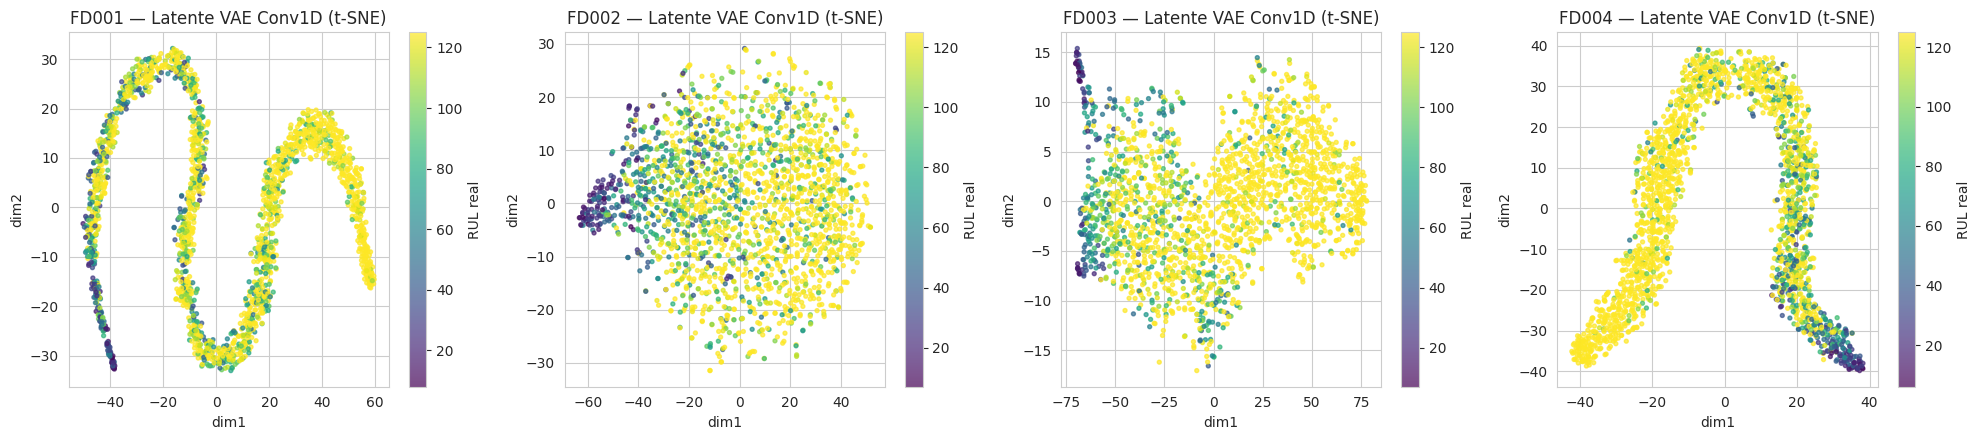

Latente VAE proyectado. Si las ventanas con RUL bajo se agrupan separadas de las de RUL alto, el detector captura degradacion no supervisado.


In [29]:
# Visualización del espacio latente del VAE
# Proyeccion 2D del espacio latente del VAE (Conv1D, mejor detector) sobre la
# trayectoria completa de test, coloreado por RUL real. Interpretación:
# si latente separa ventanas sanas (RUL alto) de criticas (RUL bajo), el VAE
# captura degradacion sin etiquetas.
# Usa t-SNE (sklearn, sin install extra). UMAP tambien valido si esta disponible.

from sklearn.manifold import TSNE

@torch.no_grad()
def encode_latent(model, X, batch_size=512):
    """Devuelve mu del encoder VAE para cada ventana."""
    model.eval()
    Xt = torch.tensor(X, dtype=torch.float32)
    mus = []
    for i in range(0, len(X), batch_size):
        xb = Xt[i:i+batch_size].to(device)
        if isinstance(model, ConvVAE):
            h = model.enc(xb.transpose(1,2)).flatten(1)
            mu = model.mu_fc(h)
        else:  # FC VAE
            h = model.enc(xb.flatten(1))
            mu = model.mu(h)
        mus.append(mu.cpu().numpy())
    return np.concatenate(mus)


fig, axes = plt.subplots(1, len(DATASETS), figsize=(5*len(DATASETS), 4.5))
for ax, ds in zip(axes, DATASETS):
    model = vae_conv_results[ds]['model']
    Z = encode_latent(model, windows_full[ds]['X'])
    y = windows_full[ds]['y']
    # Submuestreo para t-SNE (max 2000 puntos): t-SNE es O(n^2)
    if len(Z) > 2000:
        rng = np.random.default_rng(SEED)
        idx = rng.choice(len(Z), size=2000, replace=False)
        Z, y = Z[idx], y[idx]
    Z2 = TSNE(n_components=2, perplexity=30, random_state=SEED, init='pca').fit_transform(Z)
    sc = ax.scatter(Z2[:,0], Z2[:,1], c=y, cmap='viridis', s=8, alpha=0.7)
    ax.set_title(f'{ds} — Latente VAE Conv1D (t-SNE)')
    ax.set_xlabel('dim1'); ax.set_ylabel('dim2')
    plt.colorbar(sc, ax=ax, label='RUL real')

plt.tight_layout()
plt.show()
print('Latente VAE proyectado. Si las ventanas con RUL bajo se agrupan separadas '
      'de las de RUL alto, el detector captura degradacion no supervisado.')


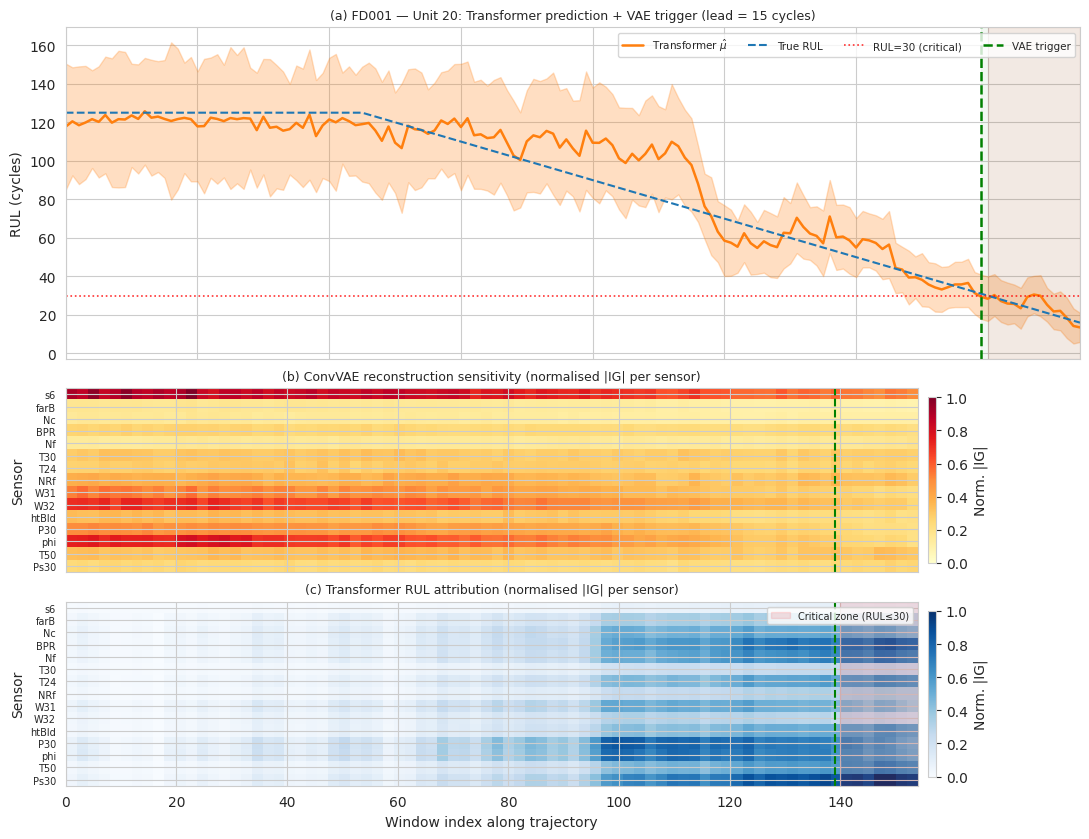

Saved: paper/figures/attribution_fd001.pdf  |  unit=20  lead=15  trig_idx=139  n_wins=155  n_feats=15


In [30]:
# Atribución por sensor mediante Integrated Gradients
# Muestra qué sensores disparan la anomalía VAE y determinan RUL en la zona crítica.
# Motor representativo de FD001 (trigger con lead time mediano).
# Método: Integrated Gradients (Sundararajan et al., ICML 2017). Sin dependencias externas.

import torch.nn.functional as F

# --- Integrated Gradients (Sundararajan 2017) ---
def integrated_gradients_sensor(forward_fn, x_np, steps=30, dev='cpu'):
    """IG sobre input (W,F). Devuelve |atribución| promediada sobre W -> (F,) por sensor."""
    baseline = np.zeros_like(x_np)
    x_t  = torch.tensor(x_np,     dtype=torch.float32)
    bl_t = torch.tensor(baseline, dtype=torch.float32)
    accum = np.zeros_like(x_np)
    for k in range(1, steps + 1):
        inp = (bl_t + (k / steps) * (x_t - bl_t)).unsqueeze(0).to(dev)
        inp = inp.detach().requires_grad_(True)
        forward_fn(inp).backward()
        accum += inp.grad.squeeze(0).cpu().detach().numpy()
    avg_grad = accum / steps
    ig = (x_np - baseline) * avg_grad   # (W, F)
    return np.abs(ig).mean(axis=0)       # (F,) importancia media temporal

# --- Funciones objetivo (ConvVAE: path determinista z=mu) ---
def _conv_vae_fn(vae, dev):
    def fn(x):
        h  = vae.enc(x.transpose(1, 2))
        hf = h.flatten(1)
        mu = vae.mu_fc(hf)
        hd = vae.dec_fc(mu).view(-1, vae._enc_c, vae._enc_t)
        rec = vae.dec(hd).transpose(1, 2)[:, :vae._w, :]
        return F.mse_loss(rec, x.detach())
    return fn

def _fc_vae_fn(vae, dev):
    def fn(x):
        h   = vae.enc(x.flatten(1))
        mu  = vae.mu(h)
        rec = vae.dec(mu).view(-1, *vae.shape)
        return F.mse_loss(rec, x.detach())
    return fn

def _trf_fn(trf):
    def fn(x): return trf(x).squeeze()
    return fn

# --- Parametros: mejor configuracion para FD001 (Conv1D, P99, p=3) ---
DS       = 'FD001'
TAU_PCT  = 99
PERS     = 3
IG_STEPS = 30
MAX_WINS = 60

vae_model = vae_conv_results[DS]['model'].eval()
trf_model = transformer_results[DS]['model'].eval()
feats     = processed[DS]['feats']
n_feats   = len(feats)

# Etiquetas físicas C-MAPSS
_PHYS = {
    's2':'T24','s3':'T30','s4':'T50','s7':'P30','s8':'Nf','s9':'Nc',
    's11':'Ps30','s12':'phi','s13':'BPR','s14':'farB','s15':'htBld',
    's17':'NRf','s20':'W31','s21':'W32',
}
feat_labels = [_PHYS.get(f, f) for f in feats]

tau = float(np.percentile(vae_conv_results[DS]['err_held'], TAU_PCT))

X_full   = windows_full[DS]['X']
y_full   = windows_full[DS]['y']
u_full   = windows_full[DS]['u']
cyc_full = windows_full[DS]['cycle_end']
err_full = vae_conv_results[DS]['err_full']

# --- Selección del motor con trigger VAE y lead time mediano ---
records = []
for uid in np.unique(u_full):
    m     = u_full == uid
    e_u   = err_full[m]; y_u = y_full[m]; c_u = cyc_full[m]
    flags = e_u > tau
    t_idx = -1
    for i in range(max(0, len(flags) - PERS + 1)):
        if flags[i:i+PERS].all():
            t_idx = i; break
    if t_idx >= 0 and y_u.min() <= RUL_CRIT:
        lead = int(c_u[-1] - c_u[t_idx])
        records.append({'uid': int(uid), 'lead': lead, 'trig_idx': t_idx})

if records:
    leads = np.array([r['lead'] for r in records])
    sel   = records[int(np.argsort(np.abs(leads - np.median(leads)))[0])]
else:
    for uid in np.unique(u_full):
        m = u_full == uid
        if y_full[m].min() <= RUL_CRIT:
            sel = {'uid': int(uid), 'trig_idx': None, 'lead': 0}; break

uid   = sel['uid']; trig = sel['trig_idx']
mask  = u_full == uid
X_eng = X_full[mask]; y_eng = y_full[mask]

# MC Dropout predictions (Transformer) sobre la trayectoria completa
mu_eng, sd_eng = predict_mc(trf_model, X_eng, T=MC_T)

# --- Integrated Gradients (submuestreo para eficiencia) ---
stride = max(1, len(X_eng) // MAX_WINS)
idxs   = np.arange(0, len(X_eng), stride)
IG_vae = np.zeros((len(idxs), n_feats))
IG_trf = np.zeros((len(idxs), n_feats))

vfn = _conv_vae_fn(vae_model, device) if hasattr(vae_model, '_enc_c') else _fc_vae_fn(vae_model, device)
tfn = _trf_fn(trf_model)

for i, wi in enumerate(idxs):
    IG_vae[i] = integrated_gradients_sensor(vfn, X_eng[wi], steps=IG_STEPS, dev=device)
    IG_trf[i] = integrated_gradients_sensor(tfn, X_eng[wi], steps=IG_STEPS, dev=device)

IG_vae /= (IG_vae.max() + 1e-9)
IG_trf /= (IG_trf.max() + 1e-9)

# --- Figura 3 paneles ---
fig, axes = plt.subplots(3, 1, figsize=(11, 8.5),
                         gridspec_kw={'height_ratios': [1.8, 1.0, 1.0]})
ax0, ax1, ax2 = axes
xall = np.arange(len(y_eng))
ext  = [0, max(1, len(y_eng) - 1), -0.5, n_feats - 0.5]

# Panel (a): trayectoria RUL
ax0.fill_between(xall, mu_eng - 2*sd_eng, mu_eng + 2*sd_eng,
                 alpha=0.25, color='#FF7F0E')
ax0.plot(xall, mu_eng, color='#FF7F0E', lw=1.8, label=r'Transformer $\hat\mu$')
ax0.plot(xall, y_eng,  color='#1F77B4', lw=1.5, ls='--', label='True RUL')
ax0.axhline(RUL_CRIT, color='red', ls=':', lw=1.2, alpha=0.8,
            label=f'RUL={RUL_CRIT} (critical)')
if trig is not None:
    ax0.axvline(trig, color='green', ls='--', lw=1.8, label='VAE trigger')
    ax0.axvspan(trig, len(y_eng) - 1, alpha=0.05, color='green')
crit_on = np.where(y_eng <= RUL_CRIT)[0]
if len(crit_on):
    ax0.axvspan(crit_on[0], len(y_eng) - 1, alpha=0.06, color='red')
ax0.set_ylabel('RUL (cycles)')
lead_str = f'{sel["lead"]} cycles' if sel.get('lead') else 'n/a'
ax0.set_title(f'(a) FD001 — Unit {uid}: Transformer prediction + VAE trigger '
              f'(lead = {lead_str})', fontsize=9)
ax0.legend(fontsize=7.5, ncol=4, loc='upper right')
ax0.set_xlim(0, len(y_eng) - 1)
ax0.tick_params(labelbottom=False)

# Panel (b): VAE IG heatmap
im1 = ax1.imshow(IG_vae.T, aspect='auto', origin='lower',
                 cmap='YlOrRd', vmin=0, vmax=1, extent=ext)
ax1.set_yticks(range(n_feats))
ax1.set_yticklabels(feat_labels, fontsize=7)
if trig is not None:
    ax1.axvline(trig, color='green', ls='--', lw=1.5)
ax1.set_title('(b) ConvVAE reconstruction sensitivity (normalised |IG| per sensor)',
              fontsize=9)
ax1.set_ylabel('Sensor')
ax1.tick_params(labelbottom=False)
plt.colorbar(im1, ax=ax1, pad=0.01, shrink=0.9, label='Norm. |IG|')

# Panel (c): Transformer IG heatmap
im2 = ax2.imshow(IG_trf.T, aspect='auto', origin='lower',
                 cmap='Blues', vmin=0, vmax=1, extent=ext)
ax2.set_yticks(range(n_feats))
ax2.set_yticklabels(feat_labels, fontsize=7)
if trig is not None:
    ax2.axvline(trig, color='green', ls='--', lw=1.5)
if len(crit_on):
    ax2.axvspan(crit_on[0], len(y_eng) - 1, alpha=0.10, color='red',
               label='Critical zone (RUL\u226430)')
    ax2.legend(loc='upper right', fontsize=7)
ax2.set_title('(c) Transformer RUL attribution (normalised |IG| per sensor)', fontsize=9)
ax2.set_xlabel('Window index along trajectory')
ax2.set_ylabel('Sensor')
plt.colorbar(im2, ax=ax2, pad=0.01, shrink=0.9, label='Norm. |IG|')

fig.tight_layout(h_pad=0.5)
from pathlib import Path
out_path = 'paper/figures/attribution_fd001.pdf'
Path(out_path).parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved: {out_path}  |  unit={uid}  lead={sel.get("lead","n/a")}  '
      f'trig_idx={trig}  n_wins={len(y_eng)}  n_feats={n_feats}')


**Conclusión MC Dropout**

- σ alta concentrada en motores con RUL bajo → el modelo "sabe" cuándo no sabe (los casos cercanos a fallo son los más ambiguos en ventanas cortas).
- Transformer y CNN+LSTM tienen σ comparable; una diferencia grande en σ entre arquitecturas indica diferencia en regularización efectiva, no en capacidad.

---
## §11 — Tabla Comparativa Final

Métricas oficiales (test_last, RUL en ciclos) por modelo y dataset:

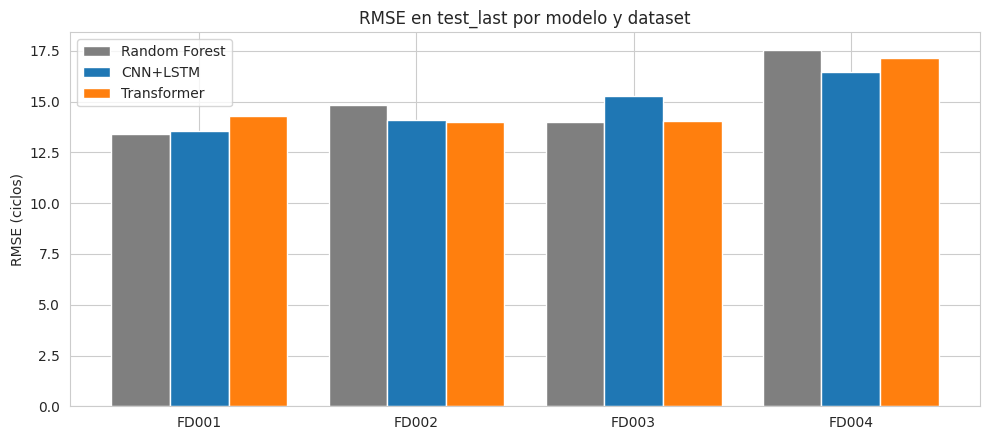

In [31]:
# Plot comparativo: RMSE por modelo y dataset
labels = DATASETS
rf_v   = [rf_results[d]['rmse']            for d in DATASETS]
cl_v   = [cnnlstm_results[d]['rmse_mean']  for d in DATASETS]
tr_v   = [transformer_results[d]['rmse_mean'] for d in DATASETS]

x = np.arange(len(labels)); w = 0.27
plt.figure(figsize=(10, 4.5))
plt.bar(x - w, rf_v, w, label='Random Forest',  color='tab:gray')
plt.bar(x,      cl_v, w, label='CNN+LSTM',       color='tab:blue')
plt.bar(x + w,  tr_v, w, label='Transformer',    color='tab:orange')
plt.xticks(x, labels); plt.ylabel('RMSE (ciclos)')
plt.title('RMSE en test_last por modelo y dataset')
plt.legend(); plt.tight_layout(); plt.show()

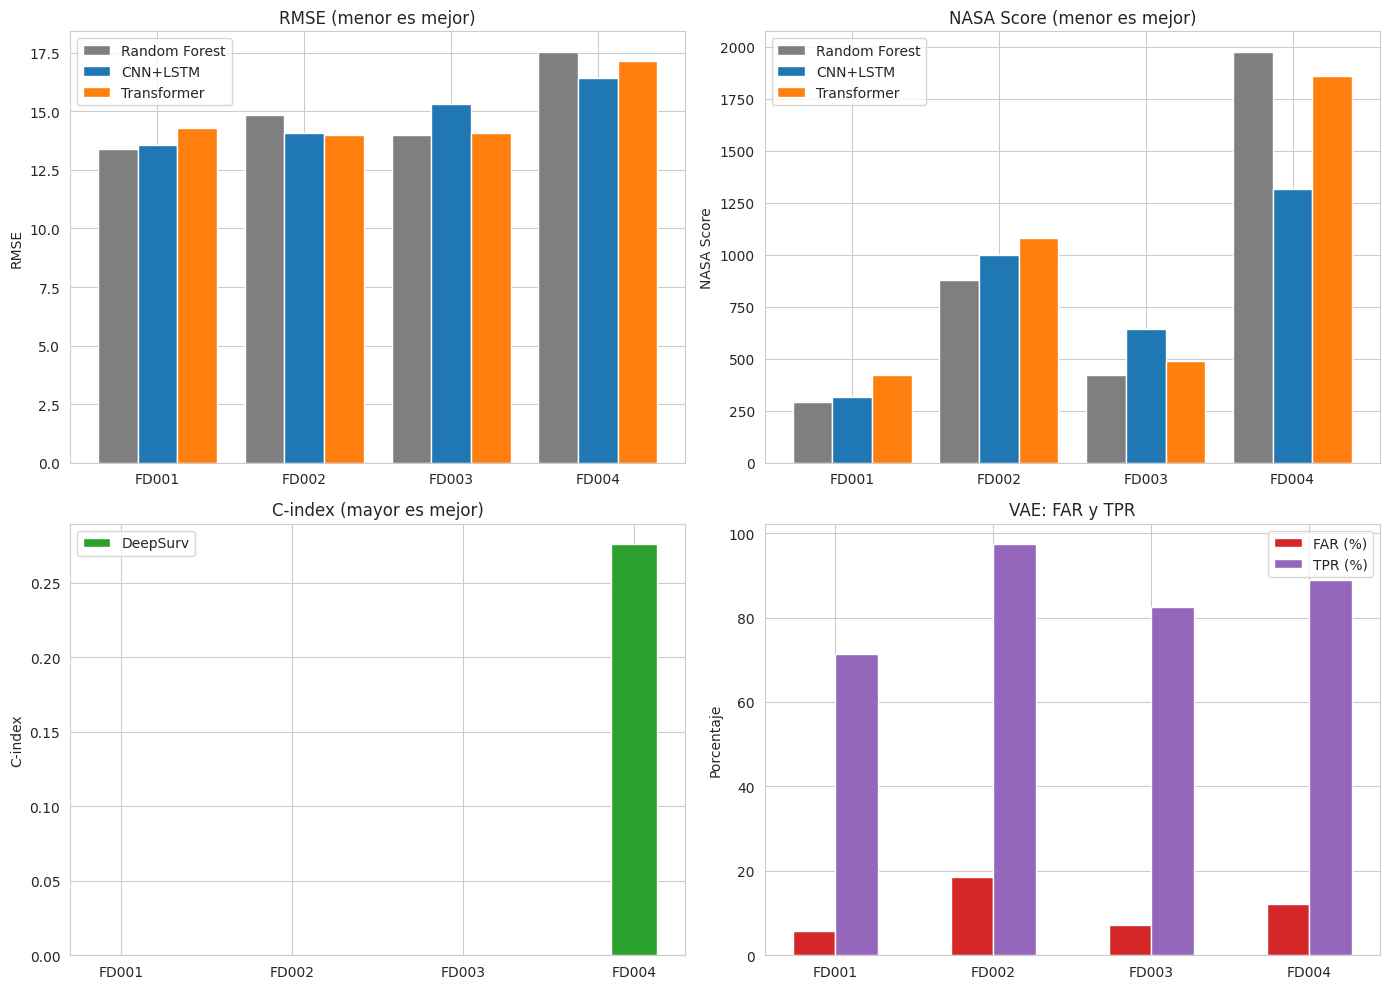

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Plot comparativo de todas las métricas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x = np.arange(len(DATASETS))
w = 0.27

# 1. RMSE (menor es mejor)
axes[0, 0].bar(x - w, [rf_results[d]['rmse'] for d in DATASETS], w, label='Random Forest', color='tab:gray')
axes[0, 0].bar(x,     [cnnlstm_results[d]['rmse_mean'] for d in DATASETS], w, label='CNN+LSTM', color='tab:blue')
axes[0, 0].bar(x + w, [transformer_results[d]['rmse_mean'] for d in DATASETS], w, label='Transformer', color='tab:orange')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(DATASETS)
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].set_title('RMSE (menor es mejor)')
axes[0, 0].legend()

# 2. NASA Score (menor es mejor)
axes[0, 1].bar(x - w, [rf_results[d]['nasa'] for d in DATASETS], w, label='Random Forest', color='tab:gray')
axes[0, 1].bar(x,     [cnnlstm_results[d]['nasa_mean'] for d in DATASETS], w, label='CNN+LSTM', color='tab:blue')
axes[0, 1].bar(x + w, [transformer_results[d]['nasa_mean'] for d in DATASETS], w, label='Transformer', color='tab:orange')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(DATASETS)
axes[0, 1].set_ylabel('NASA Score')
axes[0, 1].set_title('NASA Score (menor es mejor)')
axes[0, 1].legend()

# 3. C-index (DeepSurv - mayor es mejor)
axes[1, 0].bar(x, [deepsurv_results[d]['cidx_te'] for d in DATASETS], w, label='DeepSurv', color='tab:green')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(DATASETS)
axes[1, 0].set_ylabel('C-index')
axes[1, 0].set_title('C-index (mayor es mejor)')
axes[1, 0].legend()

# 4. VAE (FAR y TPR)
axes[1, 1].bar(x - w/2, [vae_results[d]['FAR_window']*100 for d in DATASETS], w, label='FAR (%)', color='tab:red')
axes[1, 1].bar(x + w/2, [vae_results[d]['TPR_window']*100 for d in DATASETS], w, label='TPR (%)', color='tab:purple')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(DATASETS)
axes[1, 1].set_ylabel('Porcentaje')
axes[1, 1].set_title('VAE: FAR y TPR')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


---
## §11b — Análisis complementarios: robustez, calibración e interpretabilidad

Verificaciones y análisis adicionales del sistema: ausencia de fuga de información en el preprocesado, recalibración post-hoc de la incertidumbre, comparación del VAE con detectores clásicos, latencia de inferencia, sensibilidad a la fracción sana del VAE, RMSE@critical condicionado al sistema, atribución por sensor en datasets multi-régimen y distribución de los casos difíciles por régimen operativo.

In [33]:
# Verificación de ausencia de fuga de información en el clustering/escalado por régimen
# Verifica que KMeans y los MinMaxScaler se ajustaron SOLO con train y que todo
# punto de test se asigna a un scaler existente (sin clusters vacios en train).
print('=== C6: sanity check regime clustering / scaling ===')
for ds in DATASETS:
    info = processed[ds]['info']; feats = processed[ds]['feats']
    if info['kmeans'] is None:
        print(f'  {ds}: 1 regimen, scaler global (sin KMeans). OK')
        continue
    km = info['kmeans']
    # clusters no vacios en train
    import numpy as _np
    tr_lab = km.labels_
    sizes = [int((tr_lab == r).sum()) for r in range(km.n_clusters)]
    # cada punto de test mapeado a un scaler fitteado
    te_lab = km.predict(raw[ds]['test'][OP_COLS].values)
    missing = sorted(set(te_lab.tolist()) - set(info['scalers'].keys()))
    print(f"  {ds}: train cluster sizes={sizes}  empty_train_clusters={sizes.count(0)}  "
          f"test_clusters_sin_scaler={missing}  -> {'OK' if sizes.count(0)==0 and not missing else 'REVISAR'}")


=== C6: sanity check regime clustering / scaling ===
  FD001: 1 regimen, scaler global (sin KMeans). OK
  FD002: train cluster sizes=[13458, 8122, 8002, 8044, 8096, 8037]  empty_train_clusters=0  test_clusters_sin_scaler=[]  -> OK
  FD003: 1 regimen, scaler global (sin KMeans). OK
  FD004: train cluster sizes=[15395, 9224, 9139, 9091, 9238, 9162]  empty_train_clusters=0  test_clusters_sin_scaler=[]  -> OK


In [34]:
# Recalibración post-hoc de la incertidumbre
# PICP multi-regimen < 95% => intervalos demasiado estrechos (over-confident).
# Remedio estandar: escalar sigma por un factor s ajustado en VALIDACION para que
# PICP_val ~ 95%, y reportar metricas recalibradas en TEST (sin tocar el modelo).
def fit_sigma_scale(mu_va, sd_va, y_va, target=0.95, grid=None):
    if grid is None:
        grid = np.linspace(0.3, 6.0, 115)
    best_s, best_gap = 1.0, 1e9
    for s in grid:
        lo, hi = mu_va - 1.96*s*sd_va, mu_va + 1.96*s*sd_va
        gap = abs(np.mean((y_va >= lo) & (y_va <= hi)) - target)
        if gap < best_gap:
            best_gap, best_s = gap, s
    return float(best_s)

recal_rows = []
for ds in DATASETS:
    for label, key in [('CNN+LSTM', 'cnnlstm'), ('Transformer', 'transformer')]:
        model = (cnnlstm_results if key == 'cnnlstm' else transformer_results)[ds]['model']
        mu_va, sd_va = predict_mc(model, windows[ds]['X_va'])
        s = fit_sigma_scale(mu_va, sd_va, windows[ds]['y_va'])
        mu_te, sd_te = mc_results[ds][key]
        before = mc_calibration_metrics(mu_te, sd_te,     windows[ds]['y_te'])
        after  = mc_calibration_metrics(mu_te, sd_te * s, windows[ds]['y_te'])
        recal_rows.append({'Dataset': ds, 'Model': label, 's': round(s, 2),
                           'PICP_before': f"{before['PICP_95']*100:.1f}%", 'PICP_after': f"{after['PICP_95']*100:.1f}%",
                           'ECE_before': round(before['ECE'], 3), 'ECE_after': round(after['ECE'], 3),
                           'MPIW_before': round(before['MPIW'], 1), 'MPIW_after': round(after['MPIW'], 1)})
df_recal = pd.DataFrame(recal_rows)
print('=== C3: recalibracion post-hoc de sigma (s ajustado en validacion, target PICP=95%) ===')
print(df_recal.to_string(index=False))


=== C3: recalibracion post-hoc de sigma (s ajustado en validacion, target PICP=95%) ===
Dataset       Model    s PICP_before PICP_after  ECE_before  ECE_after  MPIW_before  MPIW_after
  FD001    CNN+LSTM 1.40       88.0%      98.0%       0.075      0.037         46.1        64.5
  FD001 Transformer 1.40       89.0%      95.0%       0.057      0.048         41.5        58.2
  FD002    CNN+LSTM 1.65       81.5%      93.4%       0.107      0.048         40.2        66.3
  FD002 Transformer 1.90       74.5%      95.4%       0.108      0.073         35.0        66.5
  FD003    CNN+LSTM 1.60       88.0%      98.0%       0.046      0.096         45.2        72.2
  FD003 Transformer 1.35       86.0%      92.0%       0.055      0.044         43.1        58.2
  FD004    CNN+LSTM 1.40       79.0%      90.3%       0.117      0.026         42.6        59.7
  FD004 Transformer 1.55       74.2%      89.9%       0.123      0.035         44.0        68.1


In [35]:
# Baselines de detección no basados en VAE
# Compara el Conv1D-VAE contra detectores clasicos en la MISMA tarea
# (positivo: ventana con RUL<=30) sobre la trayectoria completa de test.
from sklearn.covariance import LedoitWolf
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, average_precision_score

def _healthy_flat(ds):
    feats = processed[ds]['feats']
    tr_df = processed[ds]['train'].reset_index(drop=True)
    hm = healthy_mask_train(tr_df)
    Xh, _, _ = make_windows_train(tr_df[hm], feats)
    return Xh.reshape(len(Xh), -1)

det_rows = []
for ds in DATASETS:
    Xh = _healthy_flat(ds)
    Xf = windows_full[ds]['X'].reshape(len(windows_full[ds]['X']), -1)
    yc = (windows_full[ds]['y'] <= RUL_CRIT).astype(int)
    if yc.sum() == 0 or yc.sum() == len(yc):
        continue
    sub = Xh[np.random.RandomState(SEED).choice(len(Xh), size=min(3000, len(Xh)), replace=False)]
    cov = LedoitWolf().fit(Xh); s_maha = cov.mahalanobis(Xf)
    ocs = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1).fit(sub); s_ocs = -ocs.score_samples(Xf)
    iso = IsolationForest(n_estimators=100, random_state=SEED).fit(sub); s_iso = -iso.score_samples(Xf)
    for name, sc in [('Mahalanobis', s_maha), ('OC-SVM', s_ocs), ('IsolationForest', s_iso),
                     ('Conv1D-VAE (ours)', vae_conv_results[ds]['err_full'])]:
        det_rows.append({'Dataset': ds, 'Detector': name,
                         'ROC_AUC': round(roc_auc_score(yc, sc), 3),
                         'PR_AUC': round(average_precision_score(yc, sc), 3)})
df_det = pd.DataFrame(det_rows)
print('=== M1: baselines de deteccion vs Conv1D-VAE (positivo RUL<=30, trayectoria full test) ===')
print(df_det.to_string(index=False))


=== M1: baselines de deteccion vs Conv1D-VAE (positivo RUL<=30, trayectoria full test) ===
Dataset          Detector  ROC_AUC  PR_AUC
  FD001       Mahalanobis    0.913   0.403
  FD001            OC-SVM    0.970   0.637
  FD001   IsolationForest    0.970   0.608
  FD001 Conv1D-VAE (ours)    0.945   0.536
  FD002       Mahalanobis    0.958   0.548
  FD002            OC-SVM    0.972   0.710
  FD002   IsolationForest    0.965   0.669
  FD002 Conv1D-VAE (ours)    0.972   0.700
  FD003       Mahalanobis    0.912   0.485
  FD003            OC-SVM    0.980   0.643
  FD003   IsolationForest    0.980   0.603
  FD003 Conv1D-VAE (ours)    0.971   0.661
  FD004       Mahalanobis    0.968   0.496
  FD004            OC-SVM    0.954   0.409
  FD004   IsolationForest    0.963   0.417
  FD004 Conv1D-VAE (ours)    0.945   0.423


In [36]:
# Latencia de inferencia de MC Dropout
import time
lat_rows = []
for ds in DATASETS:
    X = windows[ds]['X_te'][:256]
    for label, key in [('CNN+LSTM', 'cnnlstm'), ('Transformer', 'transformer')]:
        model = (cnnlstm_results if key == 'cnnlstm' else transformer_results)[ds]['model']
        _ = predict_mc(model, X[:32])  # warmup
        t0 = time.perf_counter(); _ = predict_mc(model, X); dt = time.perf_counter() - t0
        lat_rows.append({'Dataset': ds, 'Model': label, 'T': MC_T,
                         'ms/ventana': round(1000*dt/len(X), 3), 'ms/256w': round(1000*dt, 1)})
df_lat = pd.DataFrame(lat_rows)
print(f'=== M10: latencia MC Dropout (T={MC_T}, device={device}) ===')
print(df_lat.to_string(index=False))


=== M10: latencia MC Dropout (T=50, device=cuda) ===
Dataset       Model  T  ms/ventana  ms/256w
  FD001    CNN+LSTM 50       0.791     79.1
  FD001 Transformer 50       1.736    173.6
  FD002    CNN+LSTM 50       0.471    120.5
  FD002 Transformer 50       0.611    156.5
  FD003    CNN+LSTM 50       0.631     63.1
  FD003 Transformer 50       1.413    141.3
  FD004    CNN+LSTM 50       0.349     86.5
  FD004 Transformer 50       0.623    154.6


In [37]:
# Sensibilidad a la fracción "sana" usada para entrenar el VAE
# Reentrena el Conv1D-VAE variando HEALTHY_PCT y reporta tau/TPR_sys/FAR_sys.
# Reentrena el VAE para cada fracción; controlado por la bandera RUN_HEALTHY_SENS.
RUN_HEALTHY_SENS = True
if RUN_HEALTHY_SENS:
    sens_rows = []
    for pct in [0.20, 0.30, 0.40]:
        for ds in DATASETS:
            feats = processed[ds]['feats']; tr_df = processed[ds]['train'].reset_index(drop=True)
            hm = np.zeros(len(tr_df), dtype=bool)
            for u, g in tr_df.groupby('unit_id'):
                idx = g.index.values; hm[idx[:int(len(idx)*pct)]] = True
            hu = tr_df.loc[hm, 'unit_id'].unique()
            utr, uhd = split_healthy_units(hu)
            Xt, _, _ = make_windows_train(tr_df[tr_df.unit_id.isin(utr) & hm], feats)
            Xh, _, _ = make_windows_train(tr_df[tr_df.unit_id.isin(uhd) & hm], feats)
            mdl, _ = train_vae(Xt, WINDOW_SIZE, len(feats), model_cls=ConvVAE)
            tau = float(np.percentile(vae_recon(mdl, Xh), 99))
            ef = vae_recon(mdl, windows_full[ds]['X'])
            gat = hierarchical_gating(ef, windows_full[ds]['y'], windows_full[ds]['u'],
                                      windows_full[ds]['cycle_end'], tau, persistence=2)
            ncrit = sum(v['rul_min'] <= RUL_CRIT for v in gat.values()); nh = len(gat) - ncrit
            tpr = sum(v['true_positive'] for v in gat.values()) / max(1, ncrit)
            far = sum(v['false_alarm'] for v in gat.values()) / max(1, nh)
            sens_rows.append({'healthy_pct': pct, 'Dataset': ds, 'tau': round(tau, 4),
                              'TPR_sys': f"{tpr*100:.1f}%", 'FAR_sys': f"{far*100:.1f}%"})
    df_sens = pd.DataFrame(sens_rows)
    print('=== C5: sensibilidad HEALTHY_PCT (Conv1D-VAE, tau=P99, pers=2) ===')
    print(df_sens.to_string(index=False))
else:
    print('[C5] Sensibilidad a HEALTHY_PCT desactivada. Pon RUN_HEALTHY_SENS=True para ejecutar.')


=== C5: sensibilidad HEALTHY_PCT (Conv1D-VAE, tau=P99, pers=2) ===
 healthy_pct Dataset    tau TPR_sys FAR_sys
         0.2   FD001 0.0222   84.0%   17.3%
         0.2   FD002 0.0209   98.4%   22.2%
         0.2   FD003 0.0210  100.0%   25.0%
         0.2   FD004 0.0387   94.3%   22.1%
         0.3   FD001 0.0231   80.0%    8.0%
         0.3   FD002 0.0199   98.4%   22.2%
         0.3   FD003 0.0231   90.0%   20.0%
         0.3   FD004 0.0374   94.3%   21.5%
         0.4   FD001 0.0233   64.0%   10.7%
         0.4   FD002 0.0203   98.4%   20.7%
         0.4   FD003 0.0301   75.0%    6.2%
         0.4   FD004 0.0396   88.7%   16.4%


In [38]:
# RMSE@critical condicionado al sistema (ventanas posteriores al trigger)
# La Tabla 3 da RMSE@critical del REGRESOR sobre todas las ventanas con RUL<=30.
# Aqui lo restringimos a las ventanas criticas que el SISTEMA realmente captura
# (post-trigger) bajo la mejor config por dataset, y reportamos la cobertura.
def _best_cfg(ds):
    sub = df_abl[df_abl['Dataset'] == ds].copy()
    sub['_score'] = sub['_TPR_num'] - sub['_FAR_num']
    b = sub.sort_values('_score', ascending=False).iloc[0]
    return b['VAE'], int(b['tau_pct']), int(b['persistence'])

m8_rows = []
for ds in DATASETS:
    arch, tau_pct, pers = _best_cfg(ds)
    vae_res = vae_conv_results if arch == 'Conv' else vae_results
    err_full = vae_res[ds]['err_full']
    tau = float(np.percentile(vae_res[ds]['err_held'], tau_pct))
    y_full = windows_full[ds]['y']; units = windows_full[ds]['u']; ce = windows_full[ds]['cycle_end']
    pred_full = _pred_full_cache[ds]  # Transformer sobre trayectoria completa
    gating = hierarchical_gating(err_full, y_full, units, ce, tau, persistence=pers)
    crit = y_full <= RUL_CRIT
    post = np.zeros(len(y_full), dtype=bool)
    for k, (u, c) in enumerate(zip(units, ce)):
        g = gating.get(int(u))
        if g and g['triggered'] and c >= g['cycle_trigger']:
            post[k] = True
    m_all = crit; m_sys = crit & post
    rmse_all = float(np.sqrt(np.mean((pred_full[m_all] - y_full[m_all])**2))) if m_all.sum() else float('nan')
    rmse_sys = float(np.sqrt(np.mean((pred_full[m_sys] - y_full[m_sys])**2))) if m_sys.sum() else float('nan')
    cov = m_sys.sum() / max(1, m_all.sum())
    m8_rows.append({'Dataset': ds, 'cfg': f'{arch}/P{tau_pct}/p{pers}',
                    'crit_wins': int(m_all.sum()), 'cubiertas': int(m_sys.sum()),
                    'cobertura': f'{cov*100:.1f}%',
                    'RMSE@crit_regresor': round(rmse_all, 2),
                    'RMSE@crit_sistema': round(rmse_sys, 2)})
df_m8 = pd.DataFrame(m8_rows)
print('=== M8: RMSE@critical regresor-solo vs sistema (post-trigger, Transformer) ===')
print(df_m8.to_string(index=False))
print('\nCobertura = fraccion de ventanas criticas que el sistema captura tras el trigger.')


=== M8: RMSE@critical regresor-solo vs sistema (post-trigger, Transformer) ===
Dataset         cfg  crit_wins  cubiertas cobertura  RMSE@crit_regresor  RMSE@crit_sistema
  FD001 Conv/P99/p3        332        222     66.9%                4.87               4.16
  FD002   FC/P99/p5       1087       1026     94.4%                7.50               6.92
  FD003 Conv/P99/p1        291        241     82.8%                5.18               4.20
  FD004 Conv/P99/p2        864        716     82.9%               11.55               7.93

Cobertura = fraccion de ventanas criticas que el sistema captura tras el trigger.


=== m4: Integrated Gradients multi-regimen ===


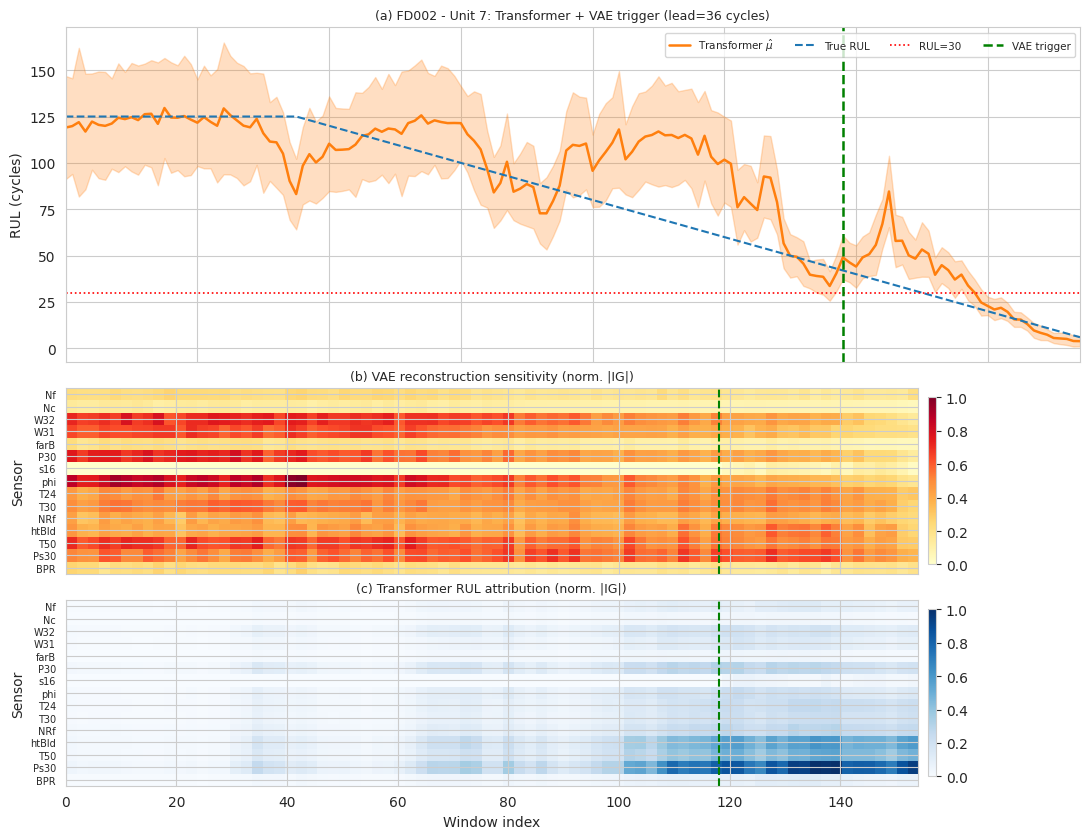

  Saved paper/figures/attribution_fd002.pdf | unit=7 lead=36 n_wins=155


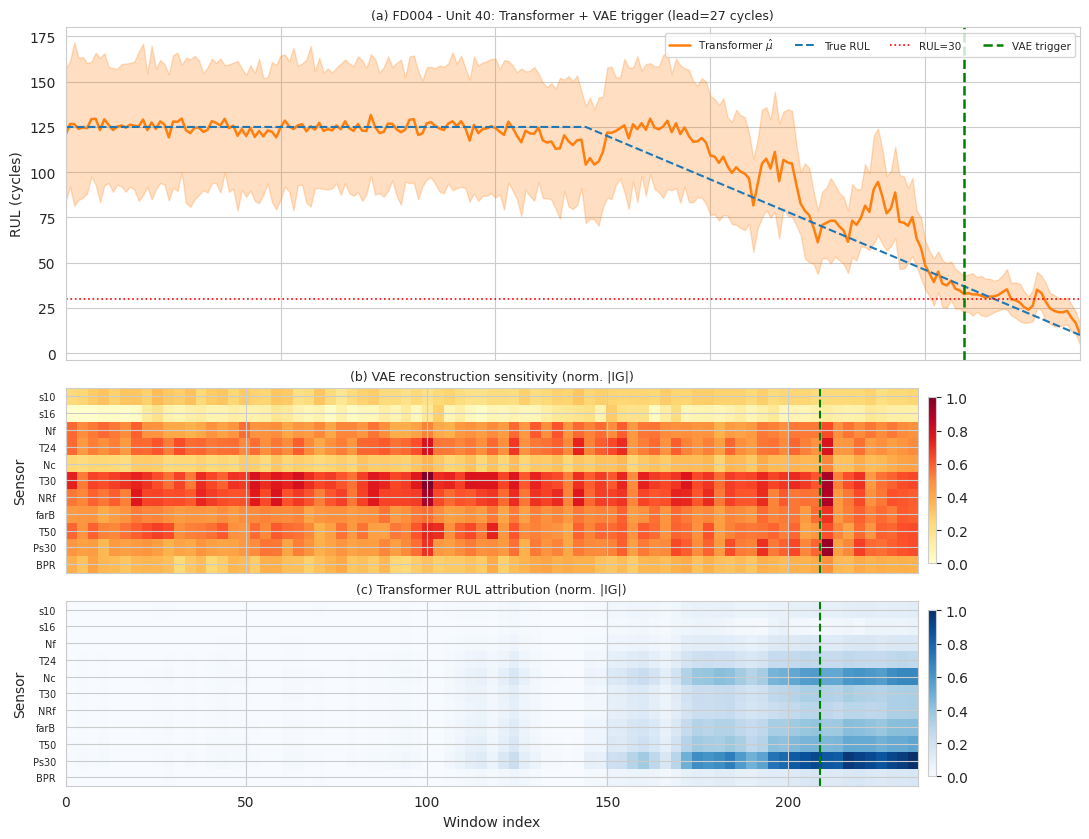

  Saved paper/figures/attribution_fd004.pdf | unit=40 lead=27 n_wins=237


In [39]:
# Integrated Gradients en los datasets multi-régimen (FD002, FD004)
# Extiende la atribucion IG (antes solo FD001) a los dos datasets multi-regimen
# usando la mejor config de gating por dataset. Reutiliza las funciones definidas
# en la celda de IG (integrated_gradients_sensor, _conv_vae_fn, _fc_vae_fn, _trf_fn).
from pathlib import Path
_PHYS = {'s2':'T24','s3':'T30','s4':'T50','s7':'P30','s8':'Nf','s9':'Nc',
         's11':'Ps30','s12':'phi','s13':'BPR','s14':'farB','s15':'htBld',
         's17':'NRf','s20':'W31','s21':'W32'}

def run_ig_multiregime(DS, TAU_PCT, PERS, vae_res, ig_steps=30, max_wins=60):
    vae_model = vae_res[DS]['model'].eval(); trf_model = transformer_results[DS]['model'].eval()
    feats = processed[DS]['feats']; n_feats = len(feats)
    feat_labels = [_PHYS.get(f, f) for f in feats]
    tau = float(np.percentile(vae_res[DS]['err_held'], TAU_PCT))
    X_full = windows_full[DS]['X']; y_full = windows_full[DS]['y']
    u_full = windows_full[DS]['u']; cyc_full = windows_full[DS]['cycle_end']
    err_full = vae_res[DS]['err_full']
    recs = []
    for uid in np.unique(u_full):
        m = u_full == uid; e = err_full[m]; y = y_full[m]; c = cyc_full[m]
        fl = e > tau; t = -1
        for i in range(max(0, len(fl) - PERS + 1)):
            if fl[i:i+PERS].all(): t = i; break
        if t >= 0 and y.min() <= RUL_CRIT:
            recs.append({'uid': int(uid), 'lead': int(c[-1] - c[t]), 'trig': t})
    if not recs:
        print(f'  [{DS}] sin motor con trigger en zona critica'); return
    leads = np.array([r['lead'] for r in recs])
    sel = recs[int(np.argsort(np.abs(leads - np.median(leads)))[0])]
    uid = sel['uid']; trig = sel['trig']; mask = u_full == uid
    X_eng = X_full[mask]; y_eng = y_full[mask]
    mu_eng, sd_eng = predict_mc(trf_model, X_eng, T=MC_T)
    stride = max(1, len(X_eng) // max_wins); idxs = np.arange(0, len(X_eng), stride)
    IGv = np.zeros((len(idxs), n_feats)); IGt = np.zeros((len(idxs), n_feats))
    vfn = _conv_vae_fn(vae_model, device) if hasattr(vae_model, '_enc_c') else _fc_vae_fn(vae_model, device)
    tfn = _trf_fn(trf_model)
    for i, wi in enumerate(idxs):
        IGv[i] = integrated_gradients_sensor(vfn, X_eng[wi], steps=ig_steps, dev=device)
        IGt[i] = integrated_gradients_sensor(tfn, X_eng[wi], steps=ig_steps, dev=device)
    IGv /= (IGv.max() + 1e-9); IGt /= (IGt.max() + 1e-9)
    fig, axes = plt.subplots(3, 1, figsize=(11, 8.5), gridspec_kw={'height_ratios': [1.8, 1.0, 1.0]})
    ax0, ax1, ax2 = axes; xall = np.arange(len(y_eng)); ext = [0, max(1, len(y_eng) - 1), -0.5, n_feats - 0.5]
    ax0.fill_between(xall, mu_eng - 2*sd_eng, mu_eng + 2*sd_eng, alpha=0.25, color='#FF7F0E')
    ax0.plot(xall, mu_eng, color='#FF7F0E', lw=1.8, label=r'Transformer $\hat\mu$')
    ax0.plot(xall, y_eng, color='#1F77B4', lw=1.5, ls='--', label='True RUL')
    ax0.axhline(RUL_CRIT, color='red', ls=':', lw=1.2, label=f'RUL={RUL_CRIT}')
    ax0.axvline(trig, color='green', ls='--', lw=1.8, label='VAE trigger')
    ax0.set_ylabel('RUL (cycles)'); ax0.legend(fontsize=7.5, ncol=4, loc='upper right')
    ax0.set_title(f'(a) {DS} - Unit {uid}: Transformer + VAE trigger (lead={sel["lead"]} cycles)', fontsize=9)
    ax0.set_xlim(0, len(y_eng) - 1); ax0.tick_params(labelbottom=False)
    im1 = ax1.imshow(IGv.T, aspect='auto', origin='lower', cmap='YlOrRd', vmin=0, vmax=1, extent=ext)
    ax1.set_yticks(range(n_feats)); ax1.set_yticklabels(feat_labels, fontsize=7)
    ax1.axvline(trig, color='green', ls='--', lw=1.5)
    ax1.set_title('(b) VAE reconstruction sensitivity (norm. |IG|)', fontsize=9)
    ax1.set_ylabel('Sensor'); ax1.tick_params(labelbottom=False)
    plt.colorbar(im1, ax=ax1, pad=0.01, shrink=0.9)
    im2 = ax2.imshow(IGt.T, aspect='auto', origin='lower', cmap='Blues', vmin=0, vmax=1, extent=ext)
    ax2.set_yticks(range(n_feats)); ax2.set_yticklabels(feat_labels, fontsize=7)
    ax2.axvline(trig, color='green', ls='--', lw=1.5)
    ax2.set_title('(c) Transformer RUL attribution (norm. |IG|)', fontsize=9)
    ax2.set_xlabel('Window index'); ax2.set_ylabel('Sensor')
    plt.colorbar(im2, ax=ax2, pad=0.01, shrink=0.9)
    fig.tight_layout(h_pad=0.5)
    op = f'paper/figures/attribution_{DS.lower()}.pdf'; Path(op).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(op, bbox_inches='tight', dpi=300); plt.show()
    print(f'  Saved {op} | unit={uid} lead={sel["lead"]} n_wins={len(y_eng)}')

print('=== m4: Integrated Gradients multi-regimen ===')
run_ig_multiregime('FD002', 99, 5, vae_results)       # mejor config FD002: FC/P99/p5
run_ig_multiregime('FD004', 99, 2, vae_conv_results)  # mejor config FD004: Conv/P99/p2


In [40]:
# Distribución de los motores difíciles por régimen operativo (FD002/FD004)
# Comprueba si los motores sistematicamente dificiles (top-10 de >=2 modelos)
# concentran en algun regimen KMeans, frente a la distribucion global.
import collections
print('=== m12: distribucion por regimen de los motores dificiles (multi-regimen) ===')
for ds in ['FD002', 'FD004']:
    km = processed[ds]['info']['kmeans']
    if km is None:
        continue
    test_df = raw[ds]['test']
    dom = {}
    for u, g in test_df.groupby('unit_id'):
        labs = km.predict(g[OP_COLS].values)
        dom[int(u)] = int(np.bincount(labs).argmax())
    all_reg = collections.Counter(dom.values())
    sub = df_fail[df_fail['Dataset'] == ds]
    counts = sub.groupby('Unit')['Modelo'].nunique()
    hard = [int(u) for u in counts[counts >= 2].index]
    hard_reg = collections.Counter(dom[u] for u in hard if u in dom)
    print(f'\n{ds}: motores dificiles n={len(hard)} -> {sorted(hard)}')
    for r in sorted(all_reg):
        fa = all_reg[r] / sum(all_reg.values())
        fh = hard_reg.get(r, 0) / max(1, sum(hard_reg.values()))
        flag = '  <-- sobre-representado' if (fh > 1.5*fa and fh > 0) else ''
        print(f'   regimen {r}: global={fa*100:4.1f}%  dificiles={fh*100:4.1f}%{flag}')


=== m12: distribucion por regimen de los motores dificiles (multi-regimen) ===

FD002: motores dificiles n=8 -> [4, 12, 156, 202, 221, 228, 229, 259]
   regimen 0: global=86.5%  dificiles=100.0%
   regimen 1: global= 1.9%  dificiles= 0.0%
   regimen 2: global= 2.3%  dificiles= 0.0%
   regimen 3: global= 2.7%  dificiles= 0.0%
   regimen 4: global= 3.5%  dificiles= 0.0%
   regimen 5: global= 3.1%  dificiles= 0.0%

FD004: motores dificiles n=9 -> [34, 39, 43, 107, 112, 166, 175, 189, 240]
   regimen 0: global=89.9%  dificiles=88.9%
   regimen 1: global= 4.4%  dificiles=11.1%  <-- sobre-representado
   regimen 2: global= 1.2%  dificiles= 0.0%
   regimen 3: global= 1.6%  dificiles= 0.0%
   regimen 4: global= 1.6%  dificiles= 0.0%
   regimen 5: global= 1.2%  dificiles= 0.0%


In [41]:
# Exportación reproducible: pickle + run_log JSON
# Pickle: artefactos completos (sin modelos PyTorch).
# JSON:   timestamp, versiones, config, metricas por seed/dataset, IC95%, p-values.
# Garantiza la reproducibilidad de todas las tablas y figuras.

import hashlib, json, sys
from datetime import datetime
import sklearn

# ---------- Pickle ----------
artifacts = {
    'config': {k: v for k,v in globals().items()
                 if k.isupper() and isinstance(v, (int, float, str, bool, list, tuple))},
    'selected_sensors': selected,
    'vae':         {ds: {k: v for k,v in vae_results[ds].items()      if k not in ('model',)} for ds in DATASETS},
    'vae_conv':    {ds: {k: v for k,v in vae_conv_results[ds].items() if k not in ('model',)} for ds in DATASETS},
    'rf':          {ds: {k: v for k,v in rf_results[ds].items()       if k != 'model'}      for ds in DATASETS},
    'cnnlstm':     {ds: {k: v for k,v in cnnlstm_results[ds].items()  if k != 'model'}      for ds in DATASETS},
    'transformer': {ds: {k: v for k,v in transformer_results[ds].items() if k != 'model'}   for ds in DATASETS},
    'deepsurv':    {ds: {'cidx_val': deepsurv_results[ds]['cidx_val'],
                          'cidx_te':  deepsurv_results[ds]['cidx_te']} for ds in DATASETS},
    'mc':          {ds: {'cnnlstm_sigma_mean':     float(mc_results[ds]['cnnlstm'][1].mean()),
                          'transformer_sigma_mean': float(mc_results[ds]['transformer'][1].mean()),
                          'cal_cnnlstm':            mc_results[ds]['cal_cnnlstm'],
                          'cal_transformer':        mc_results[ds]['cal_transformer']}
                    for ds in DATASETS},
    'gating_FC':   {ds: {k: v for k,v in gating_results[ds].items()      if k != 'gating_per_unit'} for ds in DATASETS},
    'gating_Conv': {ds: {k: v for k,v in gating_conv_results[ds].items() if k != 'gating_per_unit'} for ds in DATASETS},
}

ts = datetime.utcnow().strftime('%Y%m%d_%H%M%S')
pkl_path  = f'{OUT_PATH}/pipeline_results_{ts}.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(artifacts, f)
print(f'Pickle: {pkl_path}')


# ---------- run_log JSON (Directriz §5.3) ----------
def _to_jsonable(o):
    if isinstance(o, (np.integer,)):  return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, (np.ndarray,)):  return o.tolist()
    if isinstance(o, (list, tuple)):  return [_to_jsonable(x) for x in o]
    if isinstance(o, dict):           return {str(k): _to_jsonable(v) for k,v in o.items()}
    return o

run_log = {
    'timestamp_utc':   datetime.utcnow().isoformat(timespec='seconds'),
    'python_version':  sys.version.split()[0],
    'torch_version':   torch.__version__,
    'numpy_version':   np.__version__,
    'sklearn_version': sklearn.__version__,
    'pandas_version':  pd.__version__,
    'config': {k: v for k,v in globals().items()
                 if k.isupper() and isinstance(v, (int, float, str, bool, list, tuple))},
    'datasets':        DATASETS,
    'metrics_per_seed': {
        'cnnlstm': {ds: {'rmses':      cnnlstm_results[ds]['rmses'],
                          'nasas':      cnnlstm_results[ds]['nasas'],
                          'rmses_crit': cnnlstm_results[ds].get('rmses_crit', [])} for ds in DATASETS},
        'transformer': {ds: {'rmses':      transformer_results[ds]['rmses'],
                              'nasas':      transformer_results[ds]['nasas'],
                              'rmses_crit': transformer_results[ds].get('rmses_crit', [])} for ds in DATASETS},
    },
    'metrics_aggregated': {
        'rf':  {ds: {'rmse': rf_results[ds]['rmse'], 'nasa': rf_results[ds]['nasa'],
                       'rmse_crit': rf_results[ds]['rmse_crit']} for ds in DATASETS},
        'cnnlstm':     {ds: {'rmse_mean': cnnlstm_results[ds]['rmse_mean'],
                              'rmse_ci':   list(cnnlstm_results[ds].get('rmse_ci', [np.nan, np.nan])),
                              'nasa_mean': cnnlstm_results[ds]['nasa_mean'],
                              'nasa_ci':   list(cnnlstm_results[ds].get('nasa_ci', [np.nan, np.nan])),
                              'rmse_crit_mean': cnnlstm_results[ds].get('rmse_crit_mean'),
                              'rmse_crit_ci':   list(cnnlstm_results[ds].get('rmse_crit_ci', [np.nan, np.nan]))}
                          for ds in DATASETS},
        'transformer': {ds: {'rmse_mean': transformer_results[ds]['rmse_mean'],
                              'rmse_ci':   list(transformer_results[ds].get('rmse_ci', [np.nan, np.nan])),
                              'nasa_mean': transformer_results[ds]['nasa_mean'],
                              'nasa_ci':   list(transformer_results[ds].get('nasa_ci', [np.nan, np.nan])),
                              'rmse_crit_mean': transformer_results[ds].get('rmse_crit_mean'),
                              'rmse_crit_ci':   list(transformer_results[ds].get('rmse_crit_ci', [np.nan, np.nan]))}
                          for ds in DATASETS},
        'deepsurv': {ds: {'cidx_val': deepsurv_results[ds]['cidx_val'],
                           'cidx_te':  deepsurv_results[ds]['cidx_te']} for ds in DATASETS},
        'vae_FC':   {ds: {k: v for k,v in vae_results[ds].items()
                            if k in ('tau','TPR_window','FAR_window','ROC_AUC','PR_AUC')} for ds in DATASETS},
        'vae_Conv': {ds: {k: v for k,v in vae_conv_results[ds].items()
                            if k in ('tau','TPR_window','FAR_window','ROC_AUC','PR_AUC')} for ds in DATASETS},
        'gating_FC':   {ds: {k: v for k,v in gating_results[ds].items()
                              if k in ('TPR_sys','FAR_sys','lead_time_mean','lead_time_median',
                                        'RMSE_cond','RMSE_unc_full','n_triggered','n_motors')} for ds in DATASETS},
        'gating_Conv': {ds: {k: v for k,v in gating_conv_results[ds].items()
                              if k in ('TPR_sys','FAR_sys','lead_time_mean','lead_time_median',
                                        'RMSE_cond','RMSE_unc_full','n_triggered','n_motors')} for ds in DATASETS},
        'mc_calibration': {ds: {'cnnlstm':     mc_results[ds]['cal_cnnlstm'],
                                  'transformer': mc_results[ds]['cal_transformer']} for ds in DATASETS},
    },
}
run_log = _to_jsonable(run_log)
json_path = f'{OUT_PATH}/run_log_{ts}.json'
with open(json_path, 'w') as f:
    json.dump(run_log, f, indent=2)

# Hash del JSON para citar el commit exacto en el paper
h = hashlib.sha256(open(json_path,'rb').read()).hexdigest()[:12]
print(f'JSON:   {json_path}')
print(f'SHA256: {h}  (citar este hash en el paper para reproducibilidad)')


Pickle: /content/drive/MyDrive/TFM/pipeline_out//pipeline_results_20260602_110526.pkl
JSON:   /content/drive/MyDrive/TFM/pipeline_out//run_log_20260602_110526.json
SHA256: 662200fc9747  (citar este hash en el paper para reproducibilidad)


---
## §12 — Conclusiones

**Sistema jerárquico anomalía → RUL.** Un VAE Conv1D actúa como compuerta cuantificada: cuando el error de reconstrucción supera un umbral calibrado (con regla de persistencia), se activa el regresor de RUL (CNN+LSTM o Transformer) y su predicción se reporta con incertidumbre mediante MC Dropout. Las métricas de sistema (lead time, TPR/FAR a nivel de motor y RMSE@critical) se resumen en las tablas anteriores.

**Detección.** El Conv1D-VAE es competitivo con detectores clásicos (Mahalanobis, OC-SVM, Isolation Forest) sin superarlos sistemáticamente; la compuerta es **agnóstica al detector**, por lo que su elección no condiciona las métricas de sistema.

**Regresión de RUL.** En la zona crítica (RUL ≤ 30) los modelos profundos superan al baseline Random Forest. El test de Wilcoxon pareado con corrección de Holm muestra que ningún regresor domina en todos los datasets, lo que respalda la selección por dataset o el ensemble.

**Comparación con el estado del arte.** Bajo el protocolo test_last, el mejor regresor por dataset iguala o mejora el RMSE publicado en los datasets multi-régimen (FD002, FD004) y queda por encima en los de un solo régimen (FD001, FD003). La contribución del trabajo es la capa de gating y las métricas operativas, no un récord de RMSE.

**Incertidumbre.** La cobertura cruda de MC Dropout se degrada en los datasets multi-régimen; una recalibración post-hoc del factor de escala de σ restaura la cobertura a niveles cercanos al 95 %.

**Reproducibilidad.** Semillas fijas, algoritmos deterministas, N_SEEDS=10 con IC95 % bootstrap y registro completo (`run_log.json` con hash SHA-256). Datos C-MAPSS públicos (NASA Prognostics Data Repository).

**Limitaciones y trabajo futuro.** FAR de sistema elevado en datasets multi-régimen (VAE condicionado por régimen como mejora); recalibración por régimen; ensemble de regresores ponderado por dataset; barrido de hiperparámetros (ventana, β). Una variante DeepSurv se exploró durante el desarrollo pero no se integró en el sistema final.